## LOADING DATA

In [3]:
import os, gc
import pandas as pd

SEPT_BASE = "/kaggle/input/all-month-data"
AUG_BASE = "/kaggle/input/all-august-data"
SEPT_AIT = "/kaggle/input/ait-data/AIT SEPTEMBER.xls"
AUG_AIT = "/kaggle/input/ait-data-2/AIT AUGUST.xls"

def get_full_stats(month_name, base_path, ait_path):
    print(f"\n{'='*20} TOTAL STATS: {month_name.upper()} {'='*20}")
    
    # Load AIT IDs
    ait_data = pd.read_excel(ait_path, usecols=['msgid'])
    ait_msgids = set(ait_data['msgid'].astype(str))
    
    month_num = "08" if month_name == "august" else "09"
    total_rows = 0
    ait_found_in_logs = 0
    
    for day in range(1, 32):
        day_str = f"{day:02d}"
        f_path = f"{base_path}/{month_name}_full_message_logs_{day_str}{month_num}2025.csv"
        
        if os.path.exists(f_path):
            try:
                # ADDED encoding='latin1' to fix the UnicodeDecodeError
                chunk = pd.read_csv(f_path, usecols=[0], header=None, names=['msgid'], 
                                   engine='c', low_memory=False, encoding='latin1', 
                                   on_bad_lines='skip')
                chunk['msgid'] = chunk['msgid'].astype(str)
                
                total_rows += len(chunk)
                ait_found_in_logs += chunk['msgid'].isin(ait_msgids).sum()
                
                del chunk
                gc.collect()
            except Exception as e:
                print(f"Skipping {day_str}: {e}")
    
    print(f"📈 Total Logs Scanned: {total_rows:,}")
    print(f"🎯 AIT Found in Logs:  {ait_found_in_logs:,}")
    print(f"🏠 Normal (Ham) Logs:  {total_rows - ait_found_in_logs:,}")
    print(f"📉 Fraud Percentage:   {(ait_found_in_logs/total_rows)*100:.4f}%")
    
    return total_rows, ait_found_in_logs

sept_total, sept_ait = get_full_stats("september", SEPT_BASE, SEPT_AIT)
aug_total, aug_ait = get_full_stats("august", AUG_BASE, AUG_AIT)


==================== TOTAL STATS: SEPTEMBER ====================
📈 Total Logs Scanned: 38,767,653
🎯 AIT Found in Logs:  13,456
🏠 Normal (Ham) Logs:  38,754,197
📉 Fraud Percentage:   0.0347%

==================== TOTAL STATS: AUGUST ====================
📈 Total Logs Scanned: 35,589,690
🎯 AIT Found in Logs:  13,743
🏠 Normal (Ham) Logs:  35,575,947
📉 Fraud Percentage:   0.0386%


## EDA

In [8]:
import os, gc
import pandas as pd

# Define Paths
SEPT_BASE = "/kaggle/input/all-month-data"
AUG_BASE = "/kaggle/input/all-august-data"
SEPT_AIT = "/kaggle/input/ait-data/AIT SEPTEMBER.xls"
AUG_AIT = "/kaggle/input/ait-data-2/AIT AUGUST.xls"

# 21 original columns
cols = [
    'msgid','starttime','npdus','charcode','status','bufferedstatus',
    'msgtype','charge','sourceaddr','destaddr','reason','reasontext',
    'note','smscid','inconnector','outconnector','mcc','mnc',
    'dlr_mcc','dlr_mnc','sms_content'
]

def perform_comprehensive_eda(name, path, is_csv=True):
    print(f"\n{'='*50}")
    print(f"📊 EDA SUMMARY: {name}")
    print(f"{'='*50}")
    
    df = None
    try:
        if is_csv:
            # Match file pattern for Day 01
            suffix = "092025.csv" if "SEPT" in name else "082025.csv"
            folder = "september" if "SEPT" in name else "august"
            sample_file = f"{path}/{folder}_full_message_logs_01{suffix}"
            
            if os.path.exists(sample_file):
                # usecols=range(21) ensures we only grab your specific columns
                df = pd.read_csv(sample_file, encoding='latin1', header=None, 
                                 names=cols, usecols=range(21), nrows=5000, 
                                 low_memory=False, on_bad_lines='skip', engine='c')
            else:
                print(f"❌ File not found: {sample_file}")
                return
        else:
            # Handle Excel AIT lists
            df = pd.read_excel(path).head(1000)

        if df is not None:
            print("\n📝 1. DATA HEAD (First 5 Rows):")
            display(df.head())

            print("\n🧬 2. COLUMN DATA TYPES (dtypes):")
            print(df.dtypes)

            print("\n🔍 3. NULL VALUE ANALYSIS (isnull.sum):")
            print(df.isnull().sum())

            print("\n🔍 4. Value counts of inconnector:")
            print(df['inconnector'].value_counts())

            print("\n🔍 4. Value counts of outconnector:")
            print(df['outconnector'].value_counts())
            
            print(f"\n📐 4. SAMPLE DIMENSIONS: {df.shape}")

    except Exception as e:
        print(f"❌ Error during EDA on {name}: {e}")
    
    finally:
        if df is not None:
            del df
        gc.collect()

# Execute EDA on all 4 components
perform_comprehensive_eda("SEPTEMBER RAW LOGS", SEPT_BASE, is_csv=True)
perform_comprehensive_eda("AUGUST RAW LOGS", AUG_BASE, is_csv=True)
perform_comprehensive_eda("SEPTEMBER AIT LIST (EXCEL)", SEPT_AIT, is_csv=False)
perform_comprehensive_eda("AUGUST AIT LIST (EXCEL)", AUG_AIT, is_csv=False)


📊 EDA SUMMARY: SEPTEMBER RAW LOGS

📝 1. DATA HEAD (First 5 Rows):


,msgid,starttime,npdus,charcode,status,bufferedstatus,msgtype,charge,sourceaddr,destaddr,...,reasontext,note,smscid,inconnector,outconnector,mcc,mnc,dlr_mcc,dlr_mnc,sms_content
0,2741222745,2025-09-01 00:00:00,1,3,1,\N,1,0.185,1xbet.com,237657782861,...,\N,\N,50ABDE9AC686F0619D2C000000005F89,smpp-in1,orange-grp-trans,\N,\N,\N,\N,<#> Code de verification 35124\\n9+bTjTtDfI5
1,2741222750,2025-09-01 00:00:05,1,1,1,\N,1,0.015,AfriDoctor,221772502846,...,\N,\N,701756683705228686,smpp-in1,tigosn-lcl,\N,\N,\N,\N,Vous avez RDV le mar. 02 sept. 2025 avec le Dr...
2,2741222751,2025-09-01 00:00:05,1,1,1,\N,1,0.015,AfriDoctor,221772616083,...,\N,\N,711756683834284053,smpp-in1,tigosn-lcl,\N,\N,\N,\N,Vous avez RDV le mar. 02 sept. 2025 avec le Dr...
3,2741222752,2025-09-01 00:00:05,1,1,1,\N,1,0.015,AfriDoctor,221773541379,...,\N,\N,701756683705277719,smpp-in1,tigosn-lcl,\N,\N,\N,\N,Vous avez RDV le mar. 02 sept. 2025 avec le Dr...
4,2741222753,2025-09-01 00:00:05,1,1,3,27,1,0.015,AfriDoctor,221771136363,...,\N,\N,711756683834334063,smpp-in1,tigosn-lcl,\N,\N,\N,\N,Vous avez RDV le mar. 02 sept. 2025 avec le Dr...



🧬 2. COLUMN DATA TYPES (dtypes):
msgid               int64
starttime          object
npdus              object
charcode            int64
status              int64
bufferedstatus     object
msgtype             int64
charge            float64
sourceaddr         object
destaddr           object
reason             object
reasontext         object
note               object
smscid             object
inconnector        object
outconnector       object
mcc                object
mnc                object
dlr_mcc            object
dlr_mnc            object
sms_content        object
dtype: object

🔍 3. NULL VALUE ANALYSIS (isnull.sum):
msgid             0
starttime         0
npdus             0
charcode          0
status            0
bufferedstatus    0
msgtype           0
charge            0
sourceaddr        0
destaddr          0
reason            0
reasontext        0
note              0
smscid            0
inconnector       0
outconnector      0
mcc               0
mnc               0
dlr_mc

,msgid,starttime,npdus,charcode,status,bufferedstatus,msgtype,charge,sourceaddr,destaddr,...,reasontext,note,smscid,inconnector,outconnector,mcc,mnc,dlr_mcc,dlr_mnc,sms_content
0,2670710128,2025-08-01 00:00:01,1,1.0,1.0,\N,1.0,0.0500,1xbet,2.207189e+09,...,\N,\N,0667ce-12116-7fe0d-05744-6ed26-24319,smpp-in1,bts-slv-wh,\N,\N,\N,\N,Your code is 8rxcruy2. Do not share it with an...
1,2670710131,2025-08-01 00:00:03,1,1.0,1.0,\N,1.0,0.0095,HaloCash,2.290163e+12,...,\N,\N,0896502811,smpp-in1,mtn-benin,\N,\N,\N,\N,<HaloCash> OTP- 522035.Ne pas divulguer.
2,2670710132,2025-08-01 00:00:04,1,3.0,1.0,\N,1.0,0.0630,PAYPAL,2.011253e+11,...,\N,\N,68820ef8-afe6-1538-f8e4-3b878ed615eb,smpp-in2,scarpel-ws,\N,\N,\N,\N,PayPal: 309778 is your security code. Don't sh...
3,2670710133,2025-08-01 00:00:04,1,1.0,1.0,\N,1.0,0.0065,BareFoot,2.557573e+11,...,\N,\N,151868313,smpp-in1,blesmpp2,\N,\N,\N,\N,Reminder: You have To-Do titled The Holy Spiri...
4,2670710134,2025-08-01 00:00:05,1,1.0,1.0,\N,1.0,0.0065,PAYLEO,2.557595e+11,...,\N,\N,151868321,smpp-in1,blesmpp2,\N,\N,\N,\N,Your ADVENT CONSTRUCTION account balance has b...



🧬 2. COLUMN DATA TYPES (dtypes):
msgid              object
starttime          object
npdus              object
charcode          float64
status            float64
bufferedstatus     object
msgtype           float64
charge            float64
sourceaddr         object
destaddr          float64
reason             object
reasontext         object
note               object
smscid             object
inconnector        object
outconnector       object
mcc                object
mnc                object
dlr_mcc            object
dlr_mnc            object
sms_content        object
dtype: object

🔍 3. NULL VALUE ANALYSIS (isnull.sum):
msgid             0
starttime         3
npdus             3
charcode          3
status            3
bufferedstatus    3
msgtype           3
charge            3
sourceaddr        3
destaddr          3
reason            3
reasontext        3
note              3
smscid            3
inconnector       3
outconnector      3
mcc               3
mnc               3
dlr_mc

,msgid,Timestamo,MSISDN,Sender ID,# of SMS,Content
0,2755140283,2025-09-06 01:17:00,25776928776,AzamTV MAX,1,AzamTV MAX - Your One time Password is 251496....
1,2755141795,2025-09-06 01:28:00,25762881350,AzamTV MAX,1,AzamTV MAX - Your One time Password is 001306....
2,2755141911,2025-09-06 01:29:00,25761420686,AzamTV MAX,1,AzamTV MAX - Your One time Password is 910192....
3,2755141986,2025-09-06 01:29:00,25768462076,AzamTV MAX,1,AzamTV MAX - Your One time Password is 839490....
4,2755142109,2025-09-06 01:30:00,25766101281,AzamTV MAX,1,AzamTV MAX - Your One time Password is 890285....



🧬 2. COLUMN DATA TYPES (dtypes):
msgid                 int64
Timestamo    datetime64[ns]
MSISDN                int64
Sender ID            object
# of SMS              int64
Content              object
dtype: object

🔍 3. NULL VALUE ANALYSIS (isnull.sum):
msgid        0
Timestamo    0
MSISDN       0
Sender ID    0
# of SMS     0
Content      0
dtype: int64

📐 4. SAMPLE DIMENSIONS: (1000, 6)

📊 EDA SUMMARY: AUGUST AIT LIST (EXCEL)

📝 1. DATA HEAD (First 5 Rows):


,msgid,Timestamp,MSISDN,Sender ID,No. of SMS,Content
0,2704170000,2025-08-16 13:49:06,263785348924,AzamTV MAX,1,AzamTV MAX - Your One time Password is 111408....
1,2704191268,2025-08-16 13:52:11,263785348924,AzamTV MAX,1,AzamTV MAX - Your One time Password is 944683....
2,2704397078,2025-08-16 15:07:47,263785348924,AzamTV MAX,1,AzamTV MAX - Your One time Password is 677512....
3,2704407653,2025-08-16 15:13:07,263785348924,AzamTV MAX,1,AzamTV MAX - Your One time Password is 007167....
4,2704487978,2025-08-16 15:31:27,263785335059,AzamTV MAX,1,AzamTV MAX - Your One time Password is 012591....



🧬 2. COLUMN DATA TYPES (dtypes):
msgid                  int64
Timestamp     datetime64[ns]
MSISDN                 int64
Sender ID             object
No. of SMS             int64
Content               object
dtype: object

🔍 3. NULL VALUE ANALYSIS (isnull.sum):
msgid         0
Timestamp     0
MSISDN        0
Sender ID     0
No. of SMS    0
Content       0
dtype: int64

📐 4. SAMPLE DIMENSIONS: (1000, 6)



🎨 Generating Visuals for: SEPTEMBER RAW LOGS


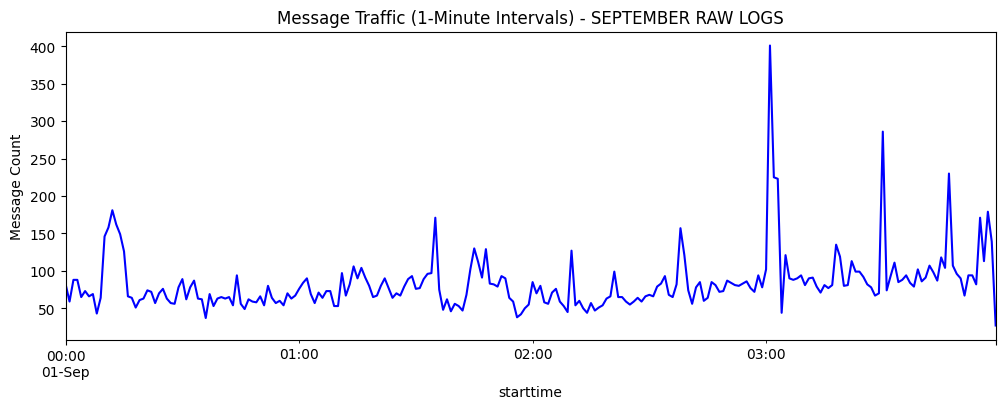

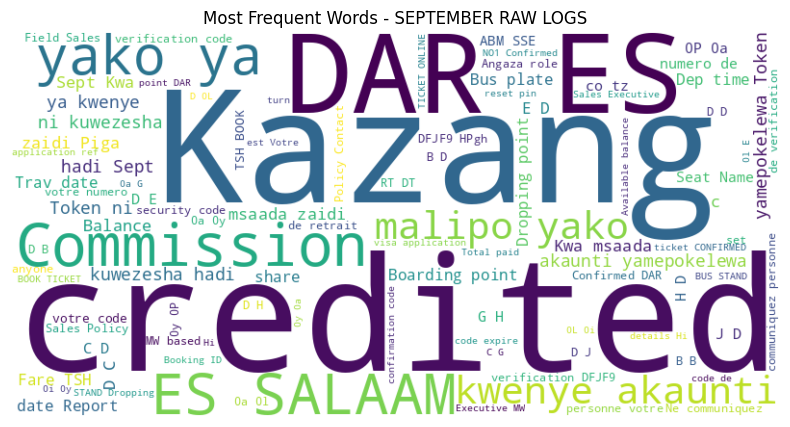


🎨 Generating Visuals for: AUGUST RAW LOGS


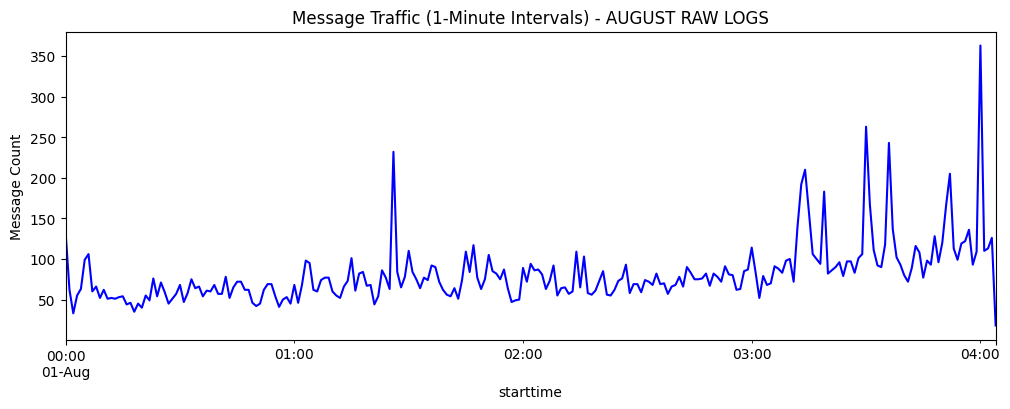

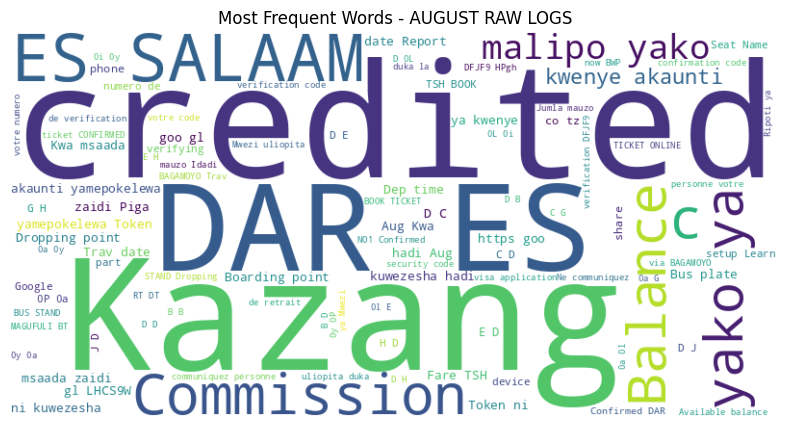


🎨 Generating Visuals for: SEPTEMBER AIT LIST


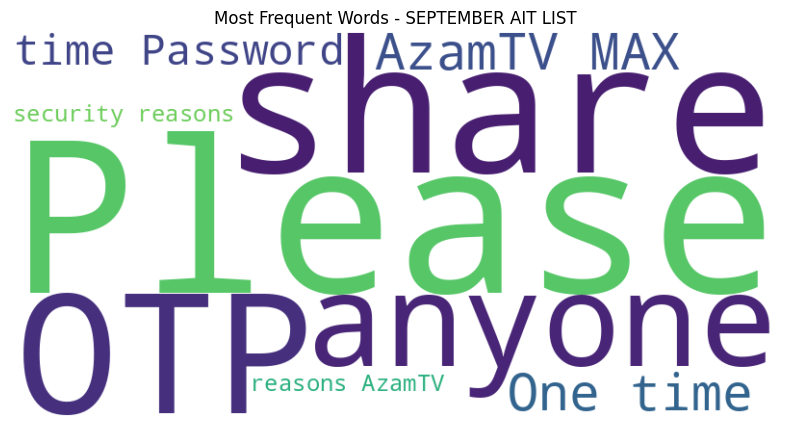


🎨 Generating Visuals for: AUGUST AIT LIST


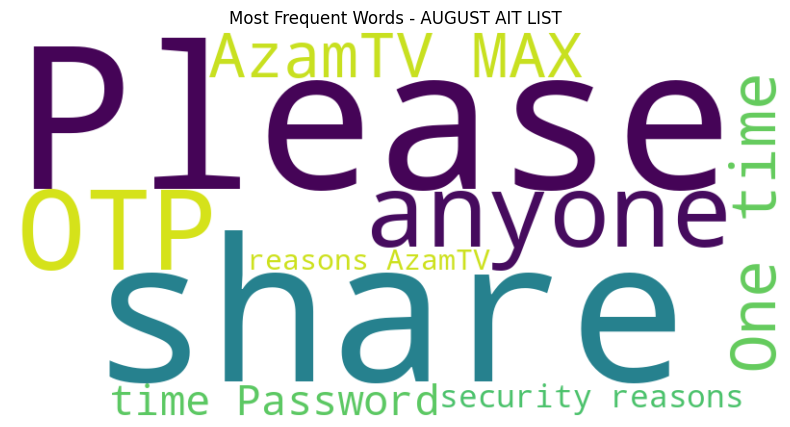

In [10]:
import os, gc
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# Paths
SEPT_BASE = "/kaggle/input/all-month-data"
AUG_BASE = "/kaggle/input/all-august-data"
SEPT_AIT = "/kaggle/input/ait-data/AIT SEPTEMBER.xls"
AUG_AIT = "/kaggle/input/ait-data-2/AIT AUGUST.xls"

cols = ['msgid','starttime','npdus','charcode','status','bufferedstatus',
        'msgtype','charge','sourceaddr','destaddr','reason','reasontext',
        'note','smscid','inconnector','outconnector','mcc','mnc',
        'dlr_mcc','dlr_mnc','sms_content']

def generate_visuals(name, path, is_csv=True):
    print(f"\n🎨 Generating Visuals for: {name}")
    df = None
    try:
        if is_csv:
            suffix = "092025.csv" if "SEPT" in name else "082025.csv"
            folder = "september" if "SEPT" in name else "august"
            # Using a larger sample (20,000 rows) for better graphs
            sample_file = f"{path}/{folder}_full_message_logs_01{suffix}"
            if os.path.exists(sample_file):
                df = pd.read_csv(sample_file, encoding='latin1', header=None, 
                                 names=cols, usecols=range(21), nrows=20000, 
                                 low_memory=False, on_bad_lines='skip')
                # 1. DRAW TRAFFIC GRAPH (Messages over time)
                df['starttime'] = pd.to_datetime(df['starttime'], errors='coerce')
                traffic = df.set_index('starttime').resample('1min').count()['msgid']
                
                plt.figure(figsize=(12, 4))
                traffic.plot(title=f"Message Traffic (1-Minute Intervals) - {name}", color='blue')
                plt.ylabel("Message Count")
                plt.show()
                
            text_col = 'sms_content'
        else:
            # For Excel (AIT Lists)
            df = pd.read_excel(path).head(5000)
            
            text_col = 'sms_content' if 'sms_content' in df.columns else df.columns[-1]

        # 2. GENERATE WORDCLOUD
        if text_col in df.columns:
            text_data = " ".join(df[text_col].astype(str).tolist())
            wordcloud = WordCloud(width=800, height=400, background_color='white', 
                                  max_words=100).generate(text_data)
            
            plt.figure(figsize=(10, 5))
            plt.imshow(wordcloud, interpolation='bilinear')
            plt.title(f"Most Frequent Words - {name}")
            plt.axis("off")
            plt.show()

    except Exception as e:
        print(f"❌ Could not generate visuals for {name}: {e}")
    finally:
        if df is not None: del df
        gc.collect()

# Run for all 4
generate_visuals("SEPTEMBER RAW LOGS", SEPT_BASE, is_csv=True)
generate_visuals("AUGUST RAW LOGS", AUG_BASE, is_csv=True)
generate_visuals("SEPTEMBER AIT LIST", SEPT_AIT, is_csv=False)
generate_visuals("AUGUST AIT LIST", AUG_AIT, is_csv=False)

## SMS CLUSTERING

In [2]:
import os
import glob
import gc
import warnings
import pandas as pd
import numpy as np
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

warnings.filterwarnings('ignore')

def clear_memory():
    gc.collect()
    print(f"🧹 Memory cleared")

clear_memory()

print("="*90)
print("SMS CONTENT CLUSTERING - Correct Column Handling")
print("="*90)

# ====================== YOUR LOCAL PATHS ======================
august_path = '/kaggle/input/all-august-data'
september_path = '/kaggle/input/all-month-data'

august_ait =  '/kaggle/input/ait-data-2/AIT AUGUST.xls'
september_ait = '/kaggle/input/ait-data/AIT SEPTEMBER.xls'

# ====================== LOAD DATA WITH PROPER COLUMN NAMES ======================
def load_for_clustering(base_path, ait_path, sample_frac=1):
    print(f"\n📂 Loading data from: {base_path} (using {sample_frac*100}% sample)...")
    
    ait_data = pd.read_excel(ait_path)
    ait_msgids = set(ait_data['msgid'].astype(str).tolist())
    
    all_files = glob.glob(os.path.join(base_path, "*.csv"))
    print(f"Found {len(all_files)} CSV files")
    
    dfs = []
    for f_path in all_files:
        # Read with header=None and assign column names 
        df_c = pd.read_csv(f_path, encoding="latin1", engine="c", on_bad_lines="skip",
                           header=None, 
                           names=['msgid', 'starttime', 'npdus', 'charcode', 'status', 'bufferedstatus',
                                  'msgtype', 'charge', 'sourceaddr', 'destaddr', 'reason', 'reasontext',
                                  'note', 'smscid', 'inconnector', 'outconnector', 'mcc', 'mnc',
                                  'dlr_mcc', 'dlr_mnc', 'sms_content'],
                           low_memory=False)
        
        df_c['msgid'] = df_c['msgid'].astype(str)
        df_c = df_c[~df_c['msgid'].isin(ait_msgids)]
        
        # Sample to save memory
        if len(df_c) > 5000:
            df_c = df_c.sample(frac=sample_frac, random_state=42)
        
        # Keep only the columns we need for clustering
        df_c = df_c[['sourceaddr', 'sms_content']]
        
        dfs.append(df_c)
        del df_c
        clear_memory()
    
    df = pd.concat(dfs, ignore_index=True).fillna('')
    print(f"Loaded {len(df):,} messages from {df['sourceaddr'].nunique():,} unique brands")
    return df

# ====================== LOAD BOTH MONTHS ======================
print("Loading August data...")
df_aug = load_for_clustering(august_path, august_ait, sample_frac=0.1)

print("\nLoading September data...")
df_sep = load_for_clustering(september_path, september_ait, sample_frac=0.1)

df = pd.concat([df_aug, df_sep], ignore_index=True)
del df_aug, df_sep
clear_memory()

# ====================== SMS CONTENT CLUSTERING ======================
print("\n🔧 Cleaning SMS content for clustering...")

def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = text.lower().strip()
    text = re.sub(r'\b\d{4,8}\b', ' OTP ', text)      # Replace OTP codes
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

df['cleaned_sms'] = df['sms_content'].apply(clean_text)

# TF-IDF Vectorization
print("Vectorizing text with TF-IDF...")
tfidf = TfidfVectorizer(
    max_features=1000,
    ngram_range=(1, 2),
    min_df=3,
    stop_words='english'
)

X_text = tfidf.fit_transform(df['cleaned_sms'])
print(f"Text feature shape: {X_text.shape}")

# Clustering
print("Running K-Means clustering on SMS content...")
best_k = 15
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df['sms_cluster'] = kmeans.fit_predict(X_text)

# ====================== RESULTS ======================
print(f"\n✅ Clustering completed with {best_k} clusters")

print("\nCluster Distribution:")
print(df['sms_cluster'].value_counts().sort_index())

print("\n🔍 TOP KEYWORDS PER CLUSTER:")
feature_names = tfidf.get_feature_names_out()

for i in range(best_k):
    center = kmeans.cluster_centers_[i]
    top_idx = center.argsort()[-15:][::-1]
    top_words = [feature_names[j] for j in top_idx]
    
    print(f"\nCluster {i}  ({df['sms_cluster'].value_counts()[i]:,} messages)")
    print("Top keywords:", ", ".join(top_words[:12]))
    
    # Show sample messages
    samples = df[df['sms_cluster'] == i]['sms_content'].head(3).tolist()
    print("Sample messages:")
    for s in samples:
        print("   →", s[:150] + "..." if len(s) > 150 else s)



clear_memory()

print("\n" + "="*80)




🧹 Memory cleared
SMS CONTENT CLUSTERING - Correct Column Handling
Loading August data...

📂 Loading data from: /kaggle/input/all-august-data (using 10.0% sample)...
Found 31 CSV files
🧹 Memory cleared
🧹 Memory cleared
🧹 Memory cleared
🧹 Memory cleared
🧹 Memory cleared
🧹 Memory cleared
🧹 Memory cleared
🧹 Memory cleared
🧹 Memory cleared
🧹 Memory cleared
🧹 Memory cleared
🧹 Memory cleared
🧹 Memory cleared
🧹 Memory cleared
🧹 Memory cleared
🧹 Memory cleared
🧹 Memory cleared
🧹 Memory cleared
🧹 Memory cleared
🧹 Memory cleared
🧹 Memory cleared
🧹 Memory cleared
🧹 Memory cleared
🧹 Memory cleared
🧹 Memory cleared
🧹 Memory cleared
🧹 Memory cleared
🧹 Memory cleared
🧹 Memory cleared
🧹 Memory cleared
🧹 Memory cleared
Loaded 3,556,021 messages from 154,737 unique brands

Loading September data...

📂 Loading data from: /kaggle/input/all-month-data (using 10.0% sample)...
Found 30 CSV files
🧹 Memory cleared
🧹 Memory cleared
🧹 Memory cleared
🧹 Memory cleared
🧹 Memory cleared
🧹 Memory cleared
🧹 Memory clea

## CUSTOMER SEGMENTATION

In [29]:
import os
import glob
import gc
import warnings
import textwrap
import pandas as pd
import numpy as np

warnings.filterwarnings('ignore')

def clear_memory():
    gc.collect()

print("="*90)
print("ADVANCED B2B CUSTOMER SEGMENTATION - PURE 10% SAMPLE RUN")
print("="*90)

# Local input paths from your Kaggle environment
august_path = '/kaggle/input/all-august-data'
september_path = '/kaggle/input/all-month-data'
august_ait =  '/kaggle/input/ait-data-2/AIT AUGUST.xls'
september_ait = '/kaggle/input/ait-data/AIT SEPTEMBER.xls'

# =====================================================================
# 1. LOAD ALL TARGET COLUMNS 
# =====================================================================
def load_rich_features(base_path, ait_path, sample_frac=0.1):
    ait_data = pd.read_excel(ait_path)
    ait_msgids = set(ait_data['msgid'].astype(str).tolist())
    
    all_files = glob.glob(os.path.join(base_path, "*.csv"))
    dfs = []
    
    full_column_names = [
        'msgid', 'starttime', 'npdus', 'charcode', 'status', 'bufferedstatus',
        'msgtype', 'charge', 'sourceaddr', 'destaddr', 'reason', 'reasontext',
        'note', 'smscid', 'inconnector', 'outconnector', 'mcc', 'mnc',
        'dlr_mcc', 'dlr_mnc', 'sms_content'
    ]
    
    target_cols = ['msgid', 'starttime', 'sourceaddr', 'destaddr', 'sms_content']
    target_indices = [full_column_names.index(col) for col in target_cols]
    
    for f_path in all_files:
        df_c = pd.read_csv(f_path, encoding="latin1", engine="c", on_bad_lines="skip",
                           header=None, 
                           usecols=target_indices, 
                           names=target_cols,
                           low_memory=False)
        
        df_c['msgid'] = df_c['msgid'].astype(str)
        df_c = df_c[~df_c['msgid'].isin(ait_msgids)]
        
        if len(df_c) > 5000:
            df_c = df_c.sample(frac=sample_frac, random_state=42)
            
        df_c['sourceaddr'] = df_c['sourceaddr'].fillna('UNKNOWN_SENDER').astype(str).str.upper().str.strip()
        dfs.append(df_c)
        del df_c
        clear_memory()
        
    return pd.concat(dfs, ignore_index=True)

print("Loading and prepping core records...")
df_aug = load_rich_features(august_path, august_ait, sample_frac=0.1)
df_aug['month'] = 'aug'

df_sep = load_rich_features(september_path, september_ait, sample_frac=0.1)
df_sep['month'] = 'sep'

df = pd.concat([df_aug, df_sep], ignore_index=True)
del df_aug, df_sep
clear_memory()

# =====================================================================
# 2. CONVERT RAW COLUMNS INTO NUMERICAL BUSINESS METRICS 
# =====================================================================
print("\n🏭 Aggregating raw behavior patterns into math indicators...")

df['msg_length'] = df['sms_content'].astype(str).str.len()
df['hour'] = pd.to_datetime(df['starttime'], errors='coerce').dt.hour

# Calculate pure sample counts per month
brand_months = df.groupby(['sourceaddr', 'month']).size().unstack(fill_value=0)
brand_months.columns = ['vol_aug', 'vol_sep']

# Calculate pure profiling metrics
brand_profile = df.groupby('sourceaddr').agg(
    unique_recipients=('destaddr', 'nunique'),
    avg_text_length=('msg_length', 'mean'),
    night_msg_ratio=('hour', lambda x: (x.isin([23, 0, 1, 2, 3, 4, 5])).sum() / len(x))
).reset_index()

# Merge metrics cleanly
b2b_matrix = pd.merge(brand_profile, brand_months, on='sourceaddr', how='left')

# Grand total is now strictly the sum of rows in our loaded dataframe sample
b2b_matrix['total_msg'] = b2b_matrix['vol_aug'] + b2b_matrix['vol_sep']

# Establish clean, un-scaled ratio metrics
b2b_matrix['recipient_to_msg_ratio'] = b2b_matrix['unique_recipients'] / (b2b_matrix['total_msg'] + 1)
b2b_matrix['volume_change_ratio'] = (b2b_matrix['vol_sep'] - b2b_matrix['vol_aug']) / (b2b_matrix['vol_aug'] + 1)

# =====================================================================
# 3. RULE ENGINE DESIGNATION (Thresholds recalibrated for the 10% sample)
# =====================================================================
print("🔮 Applying 5-Tier segmentation rules...")

def assign_segment(row):
    v = row['total_msg']
    trend = row['volume_change_ratio']
    
    # Thresholds adjusted downward to fit the exact row footprint of 10% sample
    if v >= 25000:
        return "HIGH-VALUE CORE CLIENTS"
    elif v >= 500 and trend > 0.5:
        return "HIGH UPSELL POTENTIAL (REAL GROWING TIER)"
    elif v >= 500 and trend < -0.5:
        return "CRITICAL CHURN RISKS (DROP IN ACTIVITY)"
    elif v >= 500:
        return "STANDARD ACTIVE LONG-TAIL"
    else:
        return "MICROTRANSACTIONAL SENDERS (LOW VOLUME)"

b2b_matrix['segment'] = b2b_matrix.apply(assign_segment, axis=1)

# =====================================================================
# 4. LIST MAX 50 SOURCE ADDR PER SEGMENT HORIZONTALLY
# =====================================================================
print("\n" + "="*90)
print("📋 SYSTEM SEGMENTATION LISTS (PURE SAMPLE COUNTS)")
print("="*90)

categories_order = [
    "HIGH-VALUE CORE CLIENTS",
    "HIGH UPSELL POTENTIAL (REAL GROWING TIER)",
    "CRITICAL CHURN RISKS (DROP IN ACTIVITY)",
    "STANDARD ACTIVE LONG-TAIL",
    "MICROTRANSACTIONAL SENDERS (LOW VOLUME)"
]

for segment_name in categories_order:
    segment_data = b2b_matrix[b2b_matrix['segment'] == segment_name].sort_values(by='total_msg', ascending=False)
    total_in_segment = len(segment_data)
    
    print("\n" + "#"*80)
    print(f"📊 {segment_name} ({total_in_segment} brands found)")
    print("#"*80)
    
    if total_in_segment == 0:
        print(" [No accounts matched this category within the sampled dataset limits]")
        continue
        
    display_subset = segment_data.head(50)
    
    brand_strings = []
    for idx, row in display_subset.iterrows():
        brand_strings.append(f"{row['sourceaddr']} ({int(row['total_msg']):,})")
    
    horizontal_output = " • ".join(brand_strings)
    wrapped_output = textwrap.fill(horizontal_output, width=90, initial_indent=" ", subsequent_indent=" ")
    print(wrapped_output)
        
    if total_in_segment > 50:
        print(f"\n ... and {total_in_segment - 50} more records hidden from console log to minimize chaos.")

=====================================================================
5. MASTER EXPORT
=====================================================================
b2b_matrix.to_csv('complete_b2b_customer_segments.csv', index=False)
print("\n" + "="*90)
print("💾 Complete master file safely saved to 'complete_b2b_customer_segments.csv'")
print("="*90)

ADVANCED B2B CUSTOMER SEGMENTATION - PURE 10% SAMPLE RUN
Loading and prepping core records...

🏭 Aggregating raw behavior patterns into math indicators...
🔮 Applying 5-Tier segmentation rules...

📋 SYSTEM SEGMENTATION LISTS (PURE SAMPLE COUNTS)

################################################################################
📊 HIGH-VALUE CORE CLIENTS (34 brands found)
################################################################################
 SUNKING (3,083,942) • PMBET (357,852) • UGANDA22BET (275,048) • STANCHART (215,762) •
 QUICKDRINKS (163,032) • PAYPAL (157,516) • NAIJA 22BET (146,961) • AZAMTV MAX (146,311) •
 VFS (117,604) • STREET (90,161) • SOLEVA TOGO (85,080) • WHATSAPP (71,580) • BET223
 (68,346) • 888BET (65,268) • GSB (60,080) • WAVE (59,858) • ABC BUS (49,183) • JUMIA
 (48,869) • WINNERRW (48,448) • BESTSPINS (42,132) • ABOOD BUS (41,989) • CANALBOX
 (41,123) • SUNCULTURE2 (39,936) • OTAPP (36,746) • T MAENDELEO (36,381) • AMANA BANK
 (34,411) • BETPAWA (33,866) •

## FURTHER ANALYSIS

In [4]:
import os, gc, csv
import pandas as pd

# --- CONFIG ---
data_configs = {
    "August": "/kaggle/input/all-august-data",
    "September": "/kaggle/input/all-month-data"
}


COLS = [
    'msgid','starttime','npdus','charcode','status','bufferedstatus',
    'msgtype','charge','sourceaddr','destaddr','reason','reasontext',
    'note','smscid','inconnector','outconnector','mcc','mnc',
    'dlr_mcc','dlr_mnc','sms_content'
]

# The 4 behavioral targets
target_cols = ['sourceaddr', 'destaddr', 'inconnector', 'outconnector']

def run_integrated_ait_eda(configs):
    month_summaries = {}
    sender_sets = {}

    for month, path in configs.items():
        print(f"📡 Processing {month.upper()}...")
        
        suffix = "082025.csv" if month == "August" else "092025.csv"
        folder = month.lower()
        
        month_dfs = []
        # Sample days 01, 10, and 20 for a broad snapshot
        for day in ["01", "10", "20"]:
            f_path = f"{path}/{folder}_full_message_logs_{day}{suffix}"
            
            if os.path.exists(f_path):
                try:
                   
                    df = pd.read_csv(
                        f_path, 
                        encoding='latin1', 
                        header=None, 
                        names=COLS, 
                        usecols=range(21), 
                        nrows=150000,
                        on_bad_lines='skip', 
                        engine='c',
                        quoting=csv.QUOTE_NONE
                    )
                    month_dfs.append(df[target_cols])
                except Exception as e:
                    print(f"   ⚠️ Skipping {day}: {str(e)[:50]}")

        if not month_dfs:
            print(f"   ❌ Failed to load any data for {month}.")
            continue

        combined = pd.concat(month_dfs, ignore_index=True)
        # Force to string and clean up stray characters
        for col in target_cols:
            combined[col] = combined[col].astype(str).str.strip('"')
            
        sender_sets[month] = set(combined['sourceaddr'].unique())
        month_summaries[month] = combined
        print(f"   ✅ {month} Loaded: {len(combined):,} rows.")

    # --- PART 1: SENDER CHURN ---
    if "August" in sender_sets and "September" in sender_sets:
        aug_s, sept_s = sender_sets["August"], sender_sets["September"]
        common = aug_s.intersection(sept_s)
        only_sep = sept_s.difference(aug_s)

        print("\n" + "═"*75)
        print("      PART 1: SENDER (SOURCEADDR) IDENTITY ANALYSIS")
        print("═"*75)
        print(f"🔗 COMMON Senders:     {len(common):<8} | Legitimate repeaters")
        print(f"🆕 NEW Senders (Sept): {len(only_sep):<8} | Possible new AIT sources")
        
        churn = (len(only_sep) / len(sept_s)) * 100 if sept_s else 0
        print(f"📈 CHURN RATE:         {churn:.2f}% of September senders are NEW")
        print("-" * 75)

    # --- PART 2: TOP 10 COMPARISON ---
    print("\n" + "═"*75)
    print("      PART 2: BEHAVIORAL VALUE COUNTS COMPARISON")
    print("═"*75)

    for col in target_cols:
        print(f"\n📊 TOP 10 {col.upper()}:")
        
        a_df = month_summaries.get("August", pd.DataFrame(columns=[col]))
        s_df = month_summaries.get("September", pd.DataFrame(columns=[col]))

        a_counts = a_df[col].value_counts().head(10)
        s_counts = s_df[col].value_counts().head(10)
        
        print(f"{'AUGUST VALUE':<32} {'COUNT':<10} | {'SEPTEMBER VALUE':<25} {'COUNT':<10}")
        print("-" * 80)
        
        a_idx, a_val = a_counts.index.tolist(), a_counts.values.tolist()
        s_idx, s_val = s_counts.index.tolist(), s_counts.values.tolist()
        
        for i in range(max(len(a_idx), len(s_idx))):
            an = str(a_idx[i])[:30] if i < len(a_idx) else ""
            av = str(a_val[i]) if i < len(a_val) else ""
            sn = str(s_idx[i])[:23] if i < len(s_idx) else ""
            sv = str(s_val[i]) if i < len(s_val) else ""
            print(f"{an:<32} {av:<10} | {sn:<25} {sv:<10}")

    gc.collect()

# Run the EDA
run_integrated_ait_eda(data_configs)

📡 Processing AUGUST...


/tmp/ipykernel_110/3607674257.py:41: DtypeWarning: Columns (6,7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(
/tmp/ipykernel_110/3607674257.py:41: DtypeWarning: Columns (6,7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(
/tmp/ipykernel_110/3607674257.py:41: DtypeWarning: Columns (4,6,7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(


   ✅ August Loaded: 450,000 rows.
📡 Processing SEPTEMBER...


/tmp/ipykernel_110/3607674257.py:41: DtypeWarning: Columns (4,6,7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(
/tmp/ipykernel_110/3607674257.py:41: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(
/tmp/ipykernel_110/3607674257.py:41: DtypeWarning: Columns (6,7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(


   ✅ September Loaded: 450,000 rows.

═══════════════════════════════════════════════════════════════════════════
      PART 1: SENDER (SOURCEADDR) IDENTITY ANALYSIS
═══════════════════════════════════════════════════════════════════════════
🔗 COMMON Senders:     437      | Legitimate repeaters
🆕 NEW Senders (Sept): 6145     | Possible new AIT sources
📈 CHURN RATE:         93.36% of September senders are NEW
---------------------------------------------------------------------------

═══════════════════════════════════════════════════════════════════════════
      PART 2: BEHAVIORAL VALUE COUNTS COMPARISON
═══════════════════════════════════════════════════════════════════════════

📊 TOP 10 SOURCEADDR:
AUGUST VALUE                     COUNT      | SEPTEMBER VALUE           COUNT     
--------------------------------------------------------------------------------
nan                              228809     | nan                       180026    
SUNKING                          96291   

## LIBRARIES

In [2]:
import os
import random
import re
import time
import gc
import warnings
import pandas as pd
import numpy as np

import joblib
import warnings
from collections import Counter

warnings.filterwarnings('ignore')

# Models
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.linear_model import SGDClassifier
from sklearn.svm import LinearSVC



# Metrics & Utilities
from sklearn.metrics import (accuracy_score, f1_score, precision_score,
                             recall_score, confusion_matrix)
from scipy.sparse import load_npz, vstack, csr_matrix, issparse
from sklearn.metrics.pairwise import euclidean_distances
from sklearn.cluster import MiniBatchKMeans
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import pairwise_distances

warnings.filterwarnings('ignore')


import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, Conv1D, MaxPooling1D, GlobalMaxPooling1D, Dense, Dropout, Concatenate, Bidirectional, LSTM

from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import LabelEncoder, StandardScaler
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences




## DATA PRE-PROCESSING FOR ML

In [2]:
import os
import random
import gc
import pandas as pd
import numpy as np
from collections import Counter
import warnings
import joblib

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack, save_npz

warnings.filterwarnings('ignore')

def set_reproducibility(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    print(f"✅ Reproducibility set with seed = {seed}")

def clear_memory():
    gc.collect()
    print(f"🧹 Memory cleared")

set_reproducibility(42)
clear_memory()

# ====================== CREATE TARGET DIRECTORY ======================
OUTPUT_DIR = "/kaggle/working/files"
if not os.path.exists(OUTPUT_DIR):
    os.makedirs(OUTPUT_DIR)
    print(f"📁 Created target directory at: {OUTPUT_DIR}")
else:
    print(f"📁 Target directory already exists at: {OUTPUT_DIR}")

# ====================== DATA LOADING & ENGINEERING ======================
def get_month_data(month_name, base_path, ait_path, encoder, is_train=True):
    print(f"\n📂 Loading {month_name.upper()}...")
    ait_data = pd.read_excel(ait_path)
    ait_msgids = set(ait_data['msgid'].astype(str).tolist())
    
    month_num = "08" if month_name == "august" else "09"
    dfs = []
    cols = [
        'msgid','starttime','npdus','charcode','status','bufferedstatus',
        'msgtype','charge','sourceaddr','destaddr','reason','reasontext',
        'note','smscid','inconnector','outconnector','mcc','mnc',
        'dlr_mcc','dlr_mnc','sms_content'
    ]
    
    for day in range(1, 32):
        day_str = f"{day:02d}"
        f_path = f"{base_path}/{month_name}_full_message_logs_{day_str}{month_num}2025.csv"
        if os.path.exists(f_path):
            df_c = pd.read_csv(f_path, encoding="latin1", engine="c", on_bad_lines="skip",
                               header=None, names=cols, low_memory=False)
            
            df_c['msgid'] = df_c['msgid'].astype(str)
            is_ait = df_c['msgid'].isin(ait_msgids)
            
            normal_sample = df_c[~is_ait].sample(frac=0.1, random_state=42)
            dfs.append(pd.concat([df_c[is_ait], normal_sample]))
            
            del df_c
            clear_memory()
    
    df = pd.concat(dfs, ignore_index=True).fillna('')
    df['label'] = df['msgid'].isin(ait_msgids).astype(int)
    
    dist = Counter(df['label'])
    print(f"📊 {month_name.upper()} LABEL DISTRIBUTION: Ham={dist[0]:,} | AIT={dist[1]:,}")
    
    # Full Feature Engineering
    df['starttime'] = pd.to_datetime(df['starttime'], errors='coerce')
    df['hour'] = df['starttime'].dt.hour
    df['is_weekend'] = df['starttime'].dt.weekday.apply(lambda x: 1 if x >= 5 else 0)
    df['date_min'] = df['starttime'].dt.to_period('min')
    df['date_hour'] = df['starttime'].dt.to_period('h')
    df['date_day'] = df['starttime'].dt.to_period('D')
    
    df['src_msgs_per_min'] = df.groupby(['date_min', 'sourceaddr'])['msgid'].transform('count')
    df['src_msgs_per_hr'] = df.groupby(['date_hour', 'sourceaddr'])['msgid'].transform('count')
    df['src_msgs_per_day'] = df.groupby(['date_day', 'sourceaddr'])['msgid'].transform('count')
    df['unique_dest_hr'] = df.groupby(['date_hour', 'sourceaddr'])['destaddr'].transform('nunique')
    df['unique_dest_day'] = df.groupby(['date_hour', 'sourceaddr'])['destaddr'].transform('nunique')
    df['unique_src_hr'] = df.groupby('date_hour')['sourceaddr'].transform('nunique')
    df['unique_src_day'] = df.groupby('date_day')['sourceaddr'].transform('nunique')
    df['unique_content_per_src_hr'] = df.groupby(['date_hour', 'sourceaddr'])['sms_content'].transform('nunique')
    df['unique_content_per_src_day'] = df.groupby(['date_day', 'sourceaddr'])['sms_content'].transform('nunique')
    df['dest_msgs_per_src_hr'] = df.groupby(['date_hour', 'sourceaddr', 'destaddr'])['msgid'].transform('count')
    df['dest_msgs_per_src_day'] = df.groupby(['date_day', 'sourceaddr', 'destaddr'])['msgid'].transform('count')
    df['spread_factor'] = df['unique_dest_hr'] / (df['src_msgs_per_hr'] + 1)
    df['spread_factor_day'] = df['unique_dest_day'] / (df['src_msgs_per_day'] + 1)
    
    df_sorted = df.sort_values(['destaddr', 'starttime'])
    df_sorted['dest_time_diff'] = df_sorted.groupby('destaddr')['starttime'].diff().dt.total_seconds() / 3600.0
    df['dest_time_diff_avg'] = df_sorted.groupby('destaddr')['dest_time_diff'].mean().reindex(df['destaddr']).values
    
    # Handle LabelEncoder mapping safely across training/testing chunks
    if is_train:
        df['outconnector_encoded'] = encoder.fit_transform(df['outconnector'].astype(str))
    else:
        test_inputs = df['outconnector'].astype(str).values
        train_classes = set(encoder.classes_)
        cleaned_inputs = [val if val in train_classes else 'unknown' for val in test_inputs]
        
        if 'unknown' not in train_classes:
            encoder.classes_ = np.append(encoder.classes_, 'unknown')
            
        df['outconnector_encoded'] = encoder.transform(cleaned_inputs)
    
    behavior_cols = [
        'hour', 'is_weekend','src_msgs_per_min','src_msgs_per_hr','src_msgs_per_day',
        'unique_dest_hr', 'charge', 'outconnector_encoded','dest_msgs_per_src_hr',
        'unique_src_hr','unique_content_per_src_hr','dest_time_diff_avg','spread_factor'
    ]
    
    X_beh = df[behavior_cols].apply(pd.to_numeric, errors='coerce').replace([np.inf, -np.inf], 0).fillna(0)
    
    y = df['label'].values
    text = df['sms_content'].astype(str).tolist()
    
    del df, dfs, ait_data, df_sorted
    clear_memory()
    
    return X_beh, y, text, behavior_cols

# Initialize global encoder instance
global_le = LabelEncoder()

# ====================== PROCESS DATA ======================
print("Loading August (Train)...")
X_train_beh, y_train, train_text, behavior_cols = get_month_data(
    "august", "/kaggle/input/all-august-data", "/kaggle/input/ait-data-2/AIT AUGUST.xls", 
    encoder=global_le, is_train=True
)

print("\nLoading September (Test)...")
X_test_beh, y_test, test_text, _ = get_month_data(
    "september", "/kaggle/input/all-month-data", "/kaggle/input/ait-data/AIT SEPTEMBER.xls", 
    encoder=global_le, is_train=False
)

# ====================== TF-IDF + SCALING ======================
print("\n🔡 Vectorizing text with TF-IDF (max_features=500)...")
tfidf = TfidfVectorizer(max_features=500, ngram_range=(1,2))
X_train_tfidf = tfidf.fit_transform(train_text)
X_test_tfidf = tfidf.transform(test_text)

scaler = StandardScaler()
X_train_beh_scaled = scaler.fit_transform(X_train_beh)
X_test_beh_scaled = scaler.transform(X_test_beh)

X_train_final = hstack([X_train_beh_scaled, X_train_tfidf]).tocsr()
X_test_final = hstack([X_test_beh_scaled, X_test_tfidf]).tocsr()

print(f"Final Train shape: {X_train_final.shape}")
print(f"Final Test shape : {X_test_final.shape}")
clear_memory()

# ====================== SAVE EVERYTHING TO SUBFOLDER ======================
print(f"\n💾 Saving processed features & deployment artifacts to {OUTPUT_DIR}...")

save_npz(os.path.join(OUTPUT_DIR, "X_train_final.npz"), X_train_final)
save_npz(os.path.join(OUTPUT_DIR, "X_test_final.npz"), X_test_final)

np.save(os.path.join(OUTPUT_DIR, "y_train.npy"), y_train)
np.save(os.path.join(OUTPUT_DIR, "y_test.npy"), y_test)

joblib.dump(tfidf, os.path.join(OUTPUT_DIR, "tfidf_vectorizer.pkl"))
joblib.dump(scaler, os.path.join(OUTPUT_DIR, "scaler.pkl"))
joblib.dump(global_le, os.path.join(OUTPUT_DIR, "label_encoder.pkl"))
joblib.dump(behavior_cols, os.path.join(OUTPUT_DIR, "behavior_cols.pkl"))

print(f"✅ All files written successfully to {OUTPUT_DIR}!")

print(f"\n📥 Track outputs in your notebook workspace:")
print(f"• {OUTPUT_DIR}/X_train_final.npz")
print(f"• {OUTPUT_DIR}/X_test_final.npz")
print(f"• {OUTPUT_DIR}/y_train.npy")
print(f"• {OUTPUT_DIR}/y_test.npy")
print(f"• {OUTPUT_DIR}/tfidf_vectorizer.pkl")
print(f"• {OUTPUT_DIR}/scaler.pkl")
print(f"• {OUTPUT_DIR}/label_encoder.pkl")
print(f"• {OUTPUT_DIR}/behavior_cols.pkl")

clear_memory()

✅ Reproducibility set with seed = 42
🧹 Memory cleared
📁 Created target directory at: /kaggle/working/files
Loading August (Train)...

📂 Loading AUGUST...
🧹 Memory cleared
🧹 Memory cleared
🧹 Memory cleared
🧹 Memory cleared
🧹 Memory cleared
🧹 Memory cleared
🧹 Memory cleared
🧹 Memory cleared
🧹 Memory cleared
🧹 Memory cleared
🧹 Memory cleared
🧹 Memory cleared
🧹 Memory cleared
🧹 Memory cleared
🧹 Memory cleared
🧹 Memory cleared
🧹 Memory cleared
🧹 Memory cleared
🧹 Memory cleared
🧹 Memory cleared
🧹 Memory cleared
🧹 Memory cleared
🧹 Memory cleared
🧹 Memory cleared
🧹 Memory cleared
🧹 Memory cleared
🧹 Memory cleared
🧹 Memory cleared
🧹 Memory cleared
🧹 Memory cleared
🧹 Memory cleared
📊 AUGUST LABEL DISTRIBUTION: Ham=3,556,021 | AIT=13,743
🧹 Memory cleared

Loading September (Test)...

📂 Loading SEPTEMBER...
🧹 Memory cleared
🧹 Memory cleared
🧹 Memory cleared
🧹 Memory cleared
🧹 Memory cleared
🧹 Memory cleared
🧹 Memory cleared
🧹 Memory cleared
🧹 Memory cleared
🧹 Memory cleared
🧹 Memory cleared
🧹 Memo

## TRAINING MACHINE LEARNING MODELS

In [22]:
def set_reproducibility(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    print(f"✅ Reproducibility set with seed = {seed}")

def clear_memory():
    gc.collect()
    print(f"🧹 Memory cleared")

set_reproducibility(42)
clear_memory()

# ====================== OUTPUT DIRECTORY SETUP ======================
OUTPUT_DIR = "/kaggle/working/files"
if not os.path.exists(OUTPUT_DIR):
    os.makedirs(OUTPUT_DIR)
    print(f"📁 Created directory at: {OUTPUT_DIR}")

# ====================== LOAD PREPROCESSED DATA ======================
print("📥 Loading saved binary features...")

X_train_final = load_npz(f"{OUTPUT_DIR}/X_train_final.npz")
X_test_final = load_npz(f"{OUTPUT_DIR}/X_test_final.npz")

y_train = np.load(f"{OUTPUT_DIR}/y_train.npy")
y_test = np.load(f"{OUTPUT_DIR}/y_test.npy")

print(f"Train matrix shape: {X_train_final.shape}")
print(f"Test matrix shape : {X_test_final.shape}")
print(f"Train label distribution: {np.bincount(y_train)}")
print(f"Test label distribution : {np.bincount(y_test)}")

clear_memory()

# ====================== SCALE_POS_WEIGHT ======================
spw = (y_train == 0).sum() / max((y_train == 1).sum(), 1)
spw_sqrt = np.sqrt(spw)
print(f"\n📊 Imbalance Ratio (spw): {spw:.2f} | scale_pos_weight = sqrt(spw) = {spw_sqrt:.2f}")

# ====================== MODELS CONFIGURATION ======================
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ),

    "SVM (SGD Linear)": SGDClassifier(
        loss='hinge',           # This explicitly forces it to behave as an SVM
        class_weight='balanced',
        penalty='l2',
        alpha=0.0001,
        max_iter=1000,
        random_state=42,
        n_jobs=-1
    ),

    "RandomForest": RandomForestClassifier(
        n_estimators=400,
        max_depth=8,
        min_samples_split=5,
        min_samples_leaf=2,
        max_features='sqrt',
        class_weight='balanced',
        bootstrap=True,
        oob_score=True,
        n_jobs=-1,
        random_state=42
    ),

    "XGBoost": XGBClassifier(
        n_estimators=800,
        max_depth=20,
        min_child_weight=5,
        gamma=0.1,
        subsample=0.8,
        colsample_bytree=0.7,
        learning_rate=0.04,
        scale_pos_weight=spw_sqrt,
        tree_method='hist',
        random_state=42
    ),

    "LightGBM": LGBMClassifier(
        n_estimators=800,
        max_depth=20,
        num_leaves=127,
        learning_rate=0.04,
        subsample=0.8,
        colsample_bytree=0.7,
        min_child_weight=5,
        scale_pos_weight=spw_sqrt,
        random_state=42,
        verbose=-1
    ),

    "MLP Classifier": MLPClassifier(
        hidden_layer_sizes=(128,64),
        activation='relu',
        solver='adam',
        alpha=0.001,
        learning_rate_init=0.01,
        batch_size=128,
        max_iter=1,                 
        early_stopping=True,           
        validation_fraction=0.15,
        random_state=42,
        verbose=False
    )
}

# ====================== TRAINING & EVALUATION ======================
results = []

for name, model in models.items():
    print(f"\n🚀 Training {name}...")
    
    start_train = time.time()
    model.fit(X_train_final, y_train)
    train_time = time.time() - start_train
  
    start_inf = time.time()
    y_pred = model.predict(X_test_final)
    inf_time = time.time() - start_inf
  
    latency_ms = (inf_time / len(y_test)) * 1000
    cm = confusion_matrix(y_test, y_pred)
   
    print(f"📊 {name} Confusion Matrix:")
    print(cm)
  
    results.append({
        "Model": name,
        "Accuracy": round(accuracy_score(y_test, y_pred), 4),
        "F1-Score": round(f1_score(y_test, y_pred), 4),
        "Precision": round(precision_score(y_test, y_pred), 4),
        "Recall": round(recall_score(y_test, y_pred), 4),
        "Train Time(s)": round(train_time, 2),
        "Inf Time(s)": round(inf_time, 4),
        "Lat(ms/msg)": round(latency_ms, 4)
    })
  
    print(f"✨ F1-Score: {results[-1]['F1-Score']:.4f} | Train Time: {train_time:.1f}s | Latency: {latency_ms:.4f} ms/msg")
    
    # Save the trained model binary straight into files directory
    safe_name = name.lower().replace(" ", "_").replace("(", "").replace(")", "")
    joblib.dump(model, os.path.join(OUTPUT_DIR, f"{safe_name}_model.pkl"))
    print(f"💾 Saved {name} model binary to {OUTPUT_DIR}")
    
    del y_pred
    clear_memory()

# ====================== FINAL SUMMARY ======================
print("\n" + "="*120)
print("FINAL BENCHMARK PERFORMANCE COMPARISON (Sorted by F1-Score)")
print("="*120)
comparison_df = pd.DataFrame(results)
comparison_df = comparison_df.sort_values("F1-Score", ascending=False)
print(comparison_df.to_string(index=False))
print("="*120)

# Export metrics summary straight into  directory
csv_output_path = os.path.join(OUTPUT_DIR, "Model_Benchmark_Results.csv")
comparison_df.to_csv(csv_output_path, index=False)
print(f"💾 Results successfully exported to '{csv_output_path}'")

✅ Reproducibility set with seed = 42
🧹 Memory cleared
📥 Loading saved binary features...
Train matrix shape: (3569764, 513)
Test matrix shape : (3886412, 513)
Train label distribution: [3556021   13743]
Test label distribution : [3872956   13456]
🧹 Memory cleared

📊 Imbalance Ratio (spw): 258.75 | scale_pos_weight = sqrt(spw) = 16.09

🚀 Training Logistic Regression...
📊 Logistic Regression Confusion Matrix:
[[3864249    8707]
 [   3773    9683]]
✨ F1-Score: 0.6081 | Train Time: 17.7s | Latency: 0.0001 ms/msg
💾 Saved Logistic Regression model binary to /kaggle/working/files
🧹 Memory cleared

🚀 Training SVM (SGD Linear)...
📊 SVM (SGD Linear) Confusion Matrix:
[[3869518    3438]
 [   3802    9654]]
✨ F1-Score: 0.7273 | Train Time: 12.6s | Latency: 0.0001 ms/msg
💾 Saved SVM (SGD Linear) model binary to /kaggle/working/files
🧹 Memory cleared

🚀 Training RandomForest...
📊 RandomForest Confusion Matrix:
[[3872955       1]
 [    231   13225]]
✨ F1-Score: 0.9913 | Train Time: 635.5s | Latency: 

## TRYING DIFFERENT MLP ARCHITECTURES 

## BATCH 256

In [4]:
def set_reproducibility(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    print(f"✅ Reproducibility set with seed = {seed}")

def clear_memory():
    gc.collect()
    print(f"🧹 Memory cleared")

set_reproducibility(42)
clear_memory()

# ====================== LOAD SAVED FEATURES ======================
print("Loading saved features...")

X_train_final = load_npz("/kaggle/working/files/X_train_final.npz")
X_test_final = load_npz("/kaggle/working/files/X_test_final.npz")

y_train = np.load("/kaggle/working/files/y_train.npy")
y_test = np.load("/kaggle/working/files/y_test.npy")

print(f"Train shape: {X_train_final.shape}")
print(f"Test shape : {X_test_final.shape}")
print(f"Train labels distribution: {np.bincount(y_train)}")
print(f"Test  labels distribution: {np.bincount(y_test)}")

clear_memory()

# ====================== MLP CONFIGURATIONS ======================
mlp_configs = {
    "MLP_1L_128": (128,),
    "MLP_1L_256": (256,),
    "MLP_1L_512": (512,),
    #"MLP_1L_1024": (1024,), # memory issues
    "MLP_2L_128_64": (128, 64),
    "MLP_2L_256_128": (256, 128),
    "MLP_2L_512_256": (512, 256),
   # "MLP_2L_1024_512": (1024, 512), # memory issues
    "MLP_3L_128_64_32": (128, 64, 32),
    "MLP_3L_256_128_64": (256, 128, 64),
    "MLP_3L_512_256_128": (512, 256, 128),
    #"MLP_3L_1024_512_256": (1024, 512, 256), memory issues
    "MLP_4L_256_128_64_32": (256, 128, 64, 32),
    "MLP_4L_512_256_128_64": (512, 256, 128, 64),
   # "MLP_4L_1024_512_256_128": (1024,512,256,128), # memory issues
}

print(f"Total MLP configurations: {len(mlp_configs)}\n")

# ====================== TRAINING ALL MLPs ======================
results = []

for name, hidden_layers in mlp_configs.items():
    print(f"\n🚀 Training {name} → {hidden_layers}")
    
    model = MLPClassifier(
        hidden_layer_sizes=hidden_layers,
        activation='relu',
        solver='adam',
        alpha=0.001,
        learning_rate_init=0.01,
        batch_size=256,
        max_iter=1,
        early_stopping=True,
        validation_fraction=0.15,
        random_state=42,
        verbose=False
    )
    
    start_train = time.time()
    model.fit(X_train_final, y_train)
    train_time = time.time() - start_train
    
    start_inf = time.time()
    y_pred = model.predict(X_test_final)
    inf_time = time.time() - start_inf
    
    latency_ms = (inf_time / len(y_test)) * 1000
    cm = confusion_matrix(y_test, y_pred)
    
    print(f"Confusion Matrix for {name}:")
    print(cm)
    print(f" → F1-Score: {f1_score(y_test, y_pred):.4f} | Time: {train_time:.1f}s")
    
    results.append({
        "Model": name,
        "Hidden Layers": hidden_layers,
        "Accuracy": round(accuracy_score(y_test, y_pred), 4),
        "F1-Score": round(f1_score(y_test, y_pred), 4),
        "Precision": round(precision_score(y_test, y_pred), 4),
        "Recall": round(recall_score(y_test, y_pred), 4),
        "Train Time(s)": round(train_time, 2),
        "Inf Time(s)": round(inf_time, 4),
        "Lat(ms/msg)": round(latency_ms, 4),
       
    })
    
    # Clear memory after each model
    del model, y_pred
    clear_memory()

# ====================== FINAL RESULTS ======================
print("\n" + "="*160)
print("MLP HIDDEN LAYER CONFIGURATIONS COMPARISON")
print("="*160)

df_results = pd.DataFrame(results)
df_results = df_results.sort_values("F1-Score", ascending=False)

print(df_results.to_string(index=False))
print("="*160)

df_results.to_csv("MLP_Results_Final.csv", index=False)
print("✅ Results saved to 'MLP_Results_Final.csv'")

clear_memory()

✅ Reproducibility set with seed = 42
🧹 Memory cleared
Loading saved features...
Train shape: (3569764, 513)
Test shape : (3886412, 513)
Train labels distribution: [3556021   13743]
Test  labels distribution: [3872956   13456]
🧹 Memory cleared
Total MLP configurations: 11


🚀 Training MLP_1L_128 → (128,)
Confusion Matrix for MLP_1L_128:
[[3872956       0]
 [   3846    9610]]
 → F1-Score: 0.8333 | Time: 78.9s
🧹 Memory cleared

🚀 Training MLP_1L_256 → (256,)
Confusion Matrix for MLP_1L_256:
[[3872903      53]
 [    577   12879]]
 → F1-Score: 0.9761 | Time: 137.8s
🧹 Memory cleared

🚀 Training MLP_1L_512 → (512,)
Confusion Matrix for MLP_1L_512:
[[3872956       0]
 [   3850    9606]]
 → F1-Score: 0.8331 | Time: 219.2s
🧹 Memory cleared

🚀 Training MLP_2L_128_64 → (128, 64)
Confusion Matrix for MLP_2L_128_64:
[[3872956       0]
 [   4374    9082]]
 → F1-Score: 0.8059 | Time: 86.5s
🧹 Memory cleared

🚀 Training MLP_2L_256_128 → (256, 128)
Confusion Matrix for MLP_2L_256_128:
[[3870051    2905]


## BATCH 128

In [3]:
def set_reproducibility(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    print(f"✅ Reproducibility set with seed = {seed}")

def clear_memory():
    gc.collect()
    print(f"🧹 Memory cleared")

set_reproducibility(42)
clear_memory()

# ====================== LOAD SAVED FEATURES ======================
print("Loading saved features...")

X_train_final = load_npz("/kaggle/working/files/X_train_final.npz")
X_test_final = load_npz("/kaggle/working/files/X_test_final.npz")

y_train = np.load("/kaggle/working/files/y_train.npy")
y_test = np.load("/kaggle/working/files/y_test.npy")

print(f"Train shape: {X_train_final.shape}")
print(f"Test shape : {X_test_final.shape}")
print(f"Train labels distribution: {np.bincount(y_train)}")
print(f"Test  labels distribution: {np.bincount(y_test)}")

clear_memory()

# ====================== MLP CONFIGURATIONS ======================
mlp_configs = {
    "MLP_1L_128": (128,),
    "MLP_1L_256": (256,),
    "MLP_1L_512": (512,),
    #"MLP_1L_1024": (1024,), # memory issues
    "MLP_2L_128_64": (128, 64),
    "MLP_2L_256_128": (256, 128),
    "MLP_2L_512_256": (512, 256),
   # "MLP_2L_1024_512": (1024, 512), # memory issues
    "MLP_3L_128_64_32": (128, 64, 32),
    "MLP_3L_256_128_64": (256, 128, 64),
    "MLP_3L_512_256_128": (512, 256, 128),
    #"MLP_3L_1024_512_256": (1024, 512, 256), memory issues
    "MLP_4L_256_128_64_32": (256, 128, 64, 32),
    "MLP_4L_512_256_128_64": (512, 256, 128, 64),
   # "MLP_4L_1024_512_256_128": (1024,512,256,128), # memory issues
}

print(f"Total MLP configurations: {len(mlp_configs)}\n")

# ====================== TRAINING ALL MLPs ======================
results = []

for name, hidden_layers in mlp_configs.items():
    print(f"\n🚀 Training {name} → {hidden_layers}")
    
    model = MLPClassifier(
        hidden_layer_sizes=hidden_layers,
        activation='relu',
        solver='adam',
        alpha=0.001,
        learning_rate_init=0.01,
        batch_size=128,
        max_iter=1,
        early_stopping=True,
        validation_fraction=0.15,
        random_state=42,
        verbose=False
    )
    
    start_train = time.time()
    model.fit(X_train_final, y_train)
    train_time = time.time() - start_train
    
    start_inf = time.time()
    y_pred = model.predict(X_test_final)
    inf_time = time.time() - start_inf
    
    latency_ms = (inf_time / len(y_test)) * 1000
    cm = confusion_matrix(y_test, y_pred)
    
    print(f"Confusion Matrix for {name}:")
    print(cm)
    print(f" → F1-Score: {f1_score(y_test, y_pred):.4f} | Time: {train_time:.1f}s")
    
    results.append({
        "Model": name,
        "Hidden Layers": hidden_layers,
        "Accuracy": round(accuracy_score(y_test, y_pred), 4),
        "F1-Score": round(f1_score(y_test, y_pred), 4),
        "Precision": round(precision_score(y_test, y_pred), 4),
        "Recall": round(recall_score(y_test, y_pred), 4),
        "Train Time(s)": round(train_time, 2),
        "Inf Time(s)": round(inf_time, 4),
        "Lat(ms/msg)": round(latency_ms, 4),
       
    })
    
    # Clear memory after each model
    del model, y_pred
    clear_memory()

# ====================== FINAL RESULTS ======================
print("\n" + "="*160)
print("MLP HIDDEN LAYER CONFIGURATIONS COMPARISON")
print("="*160)

df_results = pd.DataFrame(results)
df_results = df_results.sort_values("F1-Score", ascending=False)

print(df_results.to_string(index=False))
print("="*160)

df_results.to_csv("MLP_Results_Final.csv", index=False)
print("✅ Results saved to 'MLP_Results_Final.csv'")

clear_memory()

✅ Reproducibility set with seed = 42
🧹 Memory cleared
Loading saved features...
Train shape: (3569764, 513)
Test shape : (3886412, 513)
Train labels distribution: [3556021   13743]
Test  labels distribution: [3872956   13456]
🧹 Memory cleared
Total MLP configurations: 11


🚀 Training MLP_1L_128 → (128,)
Confusion Matrix for MLP_1L_128:
[[3872956       0]
 [   3842    9614]]
 → F1-Score: 0.8335 | Time: 276.2s
🧹 Memory cleared

🚀 Training MLP_1L_256 → (256,)
Confusion Matrix for MLP_1L_256:
[[3872834     122]
 [   3851    9605]]
 → F1-Score: 0.8286 | Time: 542.0s
🧹 Memory cleared

🚀 Training MLP_1L_512 → (512,)
Confusion Matrix for MLP_1L_512:
[[3872935      21]
 [   2207   11249]]
 → F1-Score: 0.9099 | Time: 1232.1s
🧹 Memory cleared

🚀 Training MLP_2L_128_64 → (128, 64)
Confusion Matrix for MLP_2L_128_64:
[[3871239    1717]
 [     72   13384]]
 → F1-Score: 0.9374 | Time: 318.1s
🧹 Memory cleared

🚀 Training MLP_2L_256_128 → (256, 128)
Confusion Matrix for MLP_2L_256_128:
[[3872919      3

## BATCH 1024

In [3]:
def set_reproducibility(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    print(f"✅ Reproducibility set with seed = {seed}")

def clear_memory():
    gc.collect()
    print(f"🧹 Memory cleared")

set_reproducibility(42)
clear_memory()

# ====================== LOAD SAVED FEATURES ======================
print("Loading saved features...")

X_train_final = load_npz("/kaggle/working/files/X_train_final.npz")
X_test_final = load_npz("/kaggle/working/files/X_test_final.npz")

y_train = np.load("/kaggle/working/files/y_train.npy")
y_test = np.load("/kaggle/working/files/y_test.npy")

print(f"Train shape: {X_train_final.shape}")
print(f"Test shape : {X_test_final.shape}")
print(f"Train labels distribution: {np.bincount(y_train)}")
print(f"Test  labels distribution: {np.bincount(y_test)}")

clear_memory()

# ====================== MLP CONFIGURATIONS ======================
mlp_configs = {
    "MLP_1L_128": (128,),
    "MLP_1L_256": (256,),
    "MLP_1L_512": (512,),
    #"MLP_1L_1024": (1024,), # memory issues
    "MLP_2L_128_64": (128, 64),
    "MLP_2L_256_128": (256, 128),
    "MLP_2L_512_256": (512, 256),
   # "MLP_2L_1024_512": (1024, 512), # memory issues
    "MLP_3L_128_64_32": (128, 64, 32),
    "MLP_3L_256_128_64": (256, 128, 64),
    "MLP_3L_512_256_128": (512, 256, 128),
    #"MLP_3L_1024_512_256": (1024, 512, 256), memory issues
    "MLP_4L_256_128_64_32": (256, 128, 64, 32),
    "MLP_4L_512_256_128_64": (512, 256, 128, 64),
   # "MLP_4L_1024_512_256_128": (1024,512,256,128), # memory issues
}

print(f"Total MLP configurations: {len(mlp_configs)}\n")

# ====================== TRAINING ALL MLPs ======================
results = []

for name, hidden_layers in mlp_configs.items():
    print(f"\n🚀 Training {name} → {hidden_layers}")
    
    model = MLPClassifier(
        hidden_layer_sizes=hidden_layers,
        activation='relu',
        solver='adam',
        alpha=0.001,
        learning_rate_init=0.01,
        batch_size=1024,
        max_iter=1,
        early_stopping=True,
        validation_fraction=0.15,
        random_state=42,
        verbose=False
    )
    
    start_train = time.time()
    model.fit(X_train_final, y_train)
    train_time = time.time() - start_train
    
    start_inf = time.time()
    y_pred = model.predict(X_test_final)
    inf_time = time.time() - start_inf
    
    latency_ms = (inf_time / len(y_test)) * 1000
    cm = confusion_matrix(y_test, y_pred)
    
    print(f"Confusion Matrix for {name}:")
    print(cm)
    print(f" → F1-Score: {f1_score(y_test, y_pred):.4f} | Time: {train_time:.1f}s")
    
    results.append({
        "Model": name,
        "Hidden Layers": hidden_layers,
        "Accuracy": round(accuracy_score(y_test, y_pred), 4),
        "F1-Score": round(f1_score(y_test, y_pred), 4),
        "Precision": round(precision_score(y_test, y_pred), 4),
        "Recall": round(recall_score(y_test, y_pred), 4),
        "Train Time(s)": round(train_time, 2),
        "Inf Time(s)": round(inf_time, 4),
        "Lat(ms/msg)": round(latency_ms, 4),
       
    })
    
    # Clear memory after each model
    del model, y_pred
    clear_memory()

# ====================== FINAL RESULTS ======================
print("\n" + "="*160)
print("MLP HIDDEN LAYER CONFIGURATIONS COMPARISON")
print("="*160)

df_results = pd.DataFrame(results)
df_results = df_results.sort_values("F1-Score", ascending=False)

print(df_results.to_string(index=False))
print("="*160)

df_results.to_csv("MLP_Results_Final.csv", index=False)
print("✅ Results saved to 'MLP_Results_Final.csv'")

clear_memory()

✅ Reproducibility set with seed = 42
🧹 Memory cleared
Loading saved features...
Train shape: (3569764, 513)
Test shape : (3886412, 513)
Train labels distribution: [3556021   13743]
Test  labels distribution: [3872956   13456]
🧹 Memory cleared
Total MLP configurations: 11


🚀 Training MLP_1L_128 → (128,)
Confusion Matrix for MLP_1L_128:
[[3872956       0]
 [   3847    9609]]
 → F1-Score: 0.8332 | Time: 34.2s
🧹 Memory cleared

🚀 Training MLP_1L_256 → (256,)
Confusion Matrix for MLP_1L_256:
[[3872954       2]
 [   3842    9614]]
 → F1-Score: 0.8334 | Time: 57.4s
🧹 Memory cleared

🚀 Training MLP_1L_512 → (512,)
Confusion Matrix for MLP_1L_512:
[[3872956       0]
 [   4467    8989]]
 → F1-Score: 0.8010 | Time: 98.6s
🧹 Memory cleared

🚀 Training MLP_2L_128_64 → (128, 64)
Confusion Matrix for MLP_2L_128_64:
[[3872956       0]
 [   3840    9616]]
 → F1-Score: 0.8336 | Time: 40.1s
🧹 Memory cleared

🚀 Training MLP_2L_256_128 → (256, 128)
Confusion Matrix for MLP_2L_256_128:
[[3872949       7]
 [

## DATA PREPROCESSING FOR DEEP LEARNING MODELS

In [3]:


def set_reproducibility(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    print(f"✅ Reproducibility set with seed = {seed}")

def clear_memory():
    gc.collect()
    print(f"🧹 Memory cleared")

set_reproducibility(42)
clear_memory()

# ====================== CONFIGURATION & DIRECTORIES ======================
OUTPUT_DIR = "/kaggle/working/deep_learning_files"
if not os.path.exists(OUTPUT_DIR):
    os.makedirs(OUTPUT_DIR)
    print(f"📁 Created deep learning output directory at: {OUTPUT_DIR}")

MAX_WORDS = 10000        # Maximum vocabulary size for tokenizer
MAX_SEQUENCE_LENGTH = 50 # Pad/truncate every SMS to exactly 50 tokens

# ====================== DATA LOADING & ENGINEERING ======================
def get_month_data(month_name, base_path, ait_path, encoder, is_train=True):
    print(f"\n📂 Loading {month_name.upper()}...")
    ait_data = pd.read_excel(ait_path)
    ait_msgids = set(ait_data['msgid'].astype(str).tolist())
    
    month_num = "08" if month_name == "august" else "09"
    dfs = []
    cols = [
        'msgid','starttime','npdus','charcode','status','bufferedstatus',
        'msgtype','charge','sourceaddr','destaddr','reason','reasontext',
        'note','smscid','inconnector','outconnector','mcc','mnc',
        'dlr_mcc','dlr_mnc','sms_content'
    ]
    
    for day in range(1, 32):
        day_str = f"{day:02d}"
        f_path = f"{base_path}/{month_name}_full_message_logs_{day_str}{month_num}2025.csv"
        if os.path.exists(f_path):
            df_c = pd.read_csv(f_path, encoding="latin1", engine="c", on_bad_lines="skip",
                               header=None, names=cols, low_memory=False)
            
            df_c['msgid'] = df_c['msgid'].astype(str)
            is_ait = df_c['msgid'].isin(ait_msgids)
            
            normal_sample = df_c[~is_ait].sample(frac=0.1, random_state=42)
            dfs.append(pd.concat([df_c[is_ait], normal_sample]))
            
            del df_c
            clear_memory()
    
    df = pd.concat(dfs, ignore_index=True).fillna('')
    df['label'] = df['msgid'].isin(ait_msgids).astype(int)
    
    dist = Counter(df['label'])
    print(f"📊 {month_name.upper()} LABEL DISTRIBUTION: Ham={dist[0]:,} | AIT={dist[1]:,}")
    
    # Behavioral Feature Engineering
    df['starttime'] = pd.to_datetime(df['starttime'], errors='coerce')
    df['hour'] = df['starttime'].dt.hour
    df['is_weekend'] = df['starttime'].dt.weekday.apply(lambda x: 1 if x >= 5 else 0)
    df['date_min'] = df['starttime'].dt.to_period('min')
    df['date_hour'] = df['starttime'].dt.to_period('h')
    df['date_day'] = df['starttime'].dt.to_period('D')
    
    df['src_msgs_per_min'] = df.groupby(['date_min', 'sourceaddr'])['msgid'].transform('count')
    df['src_msgs_per_hr'] = df.groupby(['date_hour', 'sourceaddr'])['msgid'].transform('count')
    df['src_msgs_per_day'] = df.groupby(['date_day', 'sourceaddr'])['msgid'].transform('count')
    df['unique_dest_hr'] = df.groupby(['date_hour', 'sourceaddr'])['destaddr'].transform('nunique')
    df['unique_dest_day'] = df.groupby(['date_hour', 'sourceaddr'])['destaddr'].transform('nunique')
    df['unique_src_hr'] = df.groupby('date_hour')['sourceaddr'].transform('nunique')
    df['unique_src_day'] = df.groupby('date_day')['sourceaddr'].transform('nunique')
    df['unique_content_per_src_hr'] = df.groupby(['date_hour', 'sourceaddr'])['sms_content'].transform('nunique')
    df['unique_content_per_src_day'] = df.groupby(['date_day', 'sourceaddr'])['sms_content'].transform('nunique')
    df['dest_msgs_per_src_hr'] = df.groupby(['date_hour', 'sourceaddr', 'destaddr'])['msgid'].transform('count')
    df['dest_msgs_per_src_day'] = df.groupby(['date_day', 'sourceaddr', 'destaddr'])['msgid'].transform('count')
    df['spread_factor'] = df['unique_dest_hr'] / (df['src_msgs_per_hr'] + 1)
    df['spread_factor_day'] = df['unique_dest_day'] / (df['src_msgs_per_day'] + 1)
   
    
    
    df_sorted = df.sort_values(['destaddr', 'starttime'])
    df_sorted['dest_time_diff'] = df_sorted.groupby('destaddr')['starttime'].diff().dt.total_seconds() / 3600.0
    df['dest_time_diff_avg'] = df_sorted.groupby('destaddr')['dest_time_diff'].mean().reindex(df['destaddr']).values
    
    
    if is_train:
        df['outconnector_encoded'] = encoder.fit_transform(df['outconnector'].astype(str))
    else:
        test_inputs = df['outconnector'].astype(str).values
        train_classes = set(encoder.classes_)
        cleaned_inputs = [val if val in train_classes else 'unknown' for val in test_inputs]
        
        if 'unknown' not in train_classes:
            encoder.classes_ = np.append(encoder.classes_, 'unknown')
            
        df['outconnector_encoded'] = encoder.transform(cleaned_inputs)
    
    behavior_cols = [
        'hour', 'is_weekend','src_msgs_per_min','src_msgs_per_hr','src_msgs_per_day',
        'unique_dest_hr', 'charge', 'outconnector_encoded','dest_msgs_per_src_hr',
        'unique_src_hr','unique_content_per_src_hr','dest_time_diff_avg','spread_factor'
    ]
    
    X_beh = df[behavior_cols].apply(pd.to_numeric, errors='coerce').replace([np.inf, -np.inf], 0).fillna(0)
    
    y = df['label'].values
    text = df['sms_content'].astype(str).tolist()
    
    del df, dfs, ait_data, df_sorted
    clear_memory()
    
    return X_beh, y, text, behavior_cols

# Initialize global tracking encoder instance
global_le = LabelEncoder()

# ====================== EXTRACTION ======================
X_train_beh, y_train, train_text, behavior_cols = get_month_data(
    "august", "/kaggle/input/all-august-data", "/kaggle/input/ait-data-2/AIT AUGUST.xls", 
    encoder=global_le, is_train=True
)

X_test_beh, y_test, test_text, _ = get_month_data(
    "september", "/kaggle/input/all-month-data", "/kaggle/input/ait-data/AIT SEPTEMBER.xls", 
    encoder=global_le, is_train=False
)

# ====================== SEQUENTIAL TOKENIZATION & PADDING ======================
print(f"\n🔡 Building Text Sequences (Vocab Cap={MAX_WORDS}, Sequence Length={MAX_SEQUENCE_LENGTH})...")

# Fit tokenizer ONLY on training text
tokenizer = Tokenizer(num_words=MAX_WORDS, lower=True, oov_token="<OOV>")
tokenizer.fit_on_texts(train_text)

# Map raw sentences into lists of integer indexes
X_train_seq = tokenizer.texts_to_sequences(train_text)
X_test_seq = tokenizer.texts_to_sequences(test_text)

# Uniformly pad arrays to maintain consistent structural input dimension dimensions
X_train_text_final = pad_sequences(X_train_seq, maxlen=MAX_SEQUENCE_LENGTH, padding='post', truncating='post')
X_test_text_final = pad_sequences(X_test_seq, maxlen=MAX_SEQUENCE_LENGTH, padding='post', truncating='post')

# ====================== SCALE METADATA BEHAVIORS ======================
print("⚖️ Scaling numerical behavioral features...")
scaler = StandardScaler()
X_train_beh_scaled = scaler.fit_transform(X_train_beh)
X_test_beh_scaled = scaler.transform(X_test_beh)

print(f"\nFinal Behavioral Array Shape : {X_train_beh_scaled.shape}")
print(f"Final Text Sequence Array Shape: {X_train_text_final.shape}")

# ====================== SAVE STRUCTURAL BINARIES ======================
print(f"\n💾 Archiving deep learning pipelines to {OUTPUT_DIR}...")

# Deep Learning arrays must be saved as native .npy dense matrices (not sparse .npz format)
np.save(os.path.join(OUTPUT_DIR, "X_train_beh_scaled.npy"), X_train_beh_scaled)
np.save(os.path.join(OUTPUT_DIR, "X_test_beh_scaled.npy"), X_test_beh_scaled)
np.save(os.path.join(OUTPUT_DIR, "X_train_text_final.npy"), X_train_text_final)
np.save(os.path.join(OUTPUT_DIR, "X_test_text_final.npy"), X_test_text_final)
np.save(os.path.join(OUTPUT_DIR, "y_train.npy"), y_train)
np.save(os.path.join(OUTPUT_DIR, "y_test.npy"), y_test)

# Pipelines required for live inference deployment pipeline
joblib.dump(tokenizer, os.path.join(OUTPUT_DIR, "keras_tokenizer.pkl"))
joblib.dump(scaler, os.path.join(OUTPUT_DIR, "scaler.pkl"))
joblib.dump(global_le, os.path.join(OUTPUT_DIR, "label_encoder.pkl"))
joblib.dump(behavior_cols, os.path.join(OUTPUT_DIR, "behavior_cols.pkl"))

print("✅ Data structures for deep learning successfully saved!")
clear_memory()

✅ Reproducibility set with seed = 42
🧹 Memory cleared

📂 Loading AUGUST...
🧹 Memory cleared
🧹 Memory cleared
🧹 Memory cleared
🧹 Memory cleared
🧹 Memory cleared
🧹 Memory cleared
🧹 Memory cleared
🧹 Memory cleared
🧹 Memory cleared
🧹 Memory cleared
🧹 Memory cleared
🧹 Memory cleared
🧹 Memory cleared
🧹 Memory cleared
🧹 Memory cleared
🧹 Memory cleared
🧹 Memory cleared
🧹 Memory cleared
🧹 Memory cleared
🧹 Memory cleared
🧹 Memory cleared
🧹 Memory cleared
🧹 Memory cleared
🧹 Memory cleared
🧹 Memory cleared
🧹 Memory cleared
🧹 Memory cleared
🧹 Memory cleared
🧹 Memory cleared
🧹 Memory cleared
🧹 Memory cleared
📊 AUGUST LABEL DISTRIBUTION: Ham=3,556,021 | AIT=13,743
🧹 Memory cleared

📂 Loading SEPTEMBER...
🧹 Memory cleared
🧹 Memory cleared
🧹 Memory cleared
🧹 Memory cleared
🧹 Memory cleared
🧹 Memory cleared
🧹 Memory cleared
🧹 Memory cleared
🧹 Memory cleared
🧹 Memory cleared
🧹 Memory cleared
🧹 Memory cleared
🧹 Memory cleared
🧹 Memory cleared
🧹 Memory cleared
🧹 Memory cleared
🧹 Memory cleared
🧹 Memory cle

## TRAINING CNN AND LSTM

In [2]:
import os
import gc
import time
import random
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, LSTM, Conv1D, MaxPooling1D, GlobalMaxPooling1D, Dense, Concatenate, Dropout, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, precision_score, recall_score

# ====================== REPRODUCIBILITY & RESET MANAGEMENT ======================
def set_reproducibility(seed=42):
    # 1. Standard library seeds
    random.seed(seed)
    np.random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    
    # 2. Core TensorFlow graph seed
    tf.random.set_seed(seed)
    
    # 3. Enforce Deterministic GPU Operations
    os.environ['TF_DETERMINISTIC_OPS'] = '1'
    os.environ['TF_CUDNN_DETERMINISTIC'] = '1'
    
    # Required when strict GPU operation determinism is enabled
    tf.config.experimental.enable_op_determinism() 
    
    print(f"✅ Strict Bitwise GPU Reproducibility Locked with seed = {seed}")

def clear_memory():
    gc.collect()
    tf.keras.backend.clear_session()
    print(f"🧹 Graph memory cleared")

# Force full environment resetting upfront
set_reproducibility(42)
clear_memory()

# ====================== CONFIGURATION & SETTINGS ======================
DATA_DIR = "/kaggle/working/deep_learning_files"
BATCH_SIZE = 128          
EPOCHS = 10               
EMBEDDING_DIM = 64        
MAX_WORDS = 10000         
MAX_SEQUENCE_LENGTH = 50  

# ====================== LOAD BINARIES & STRATIFIED SPLIT ======================
print("📥 Fetching engineered deep learning matrices...")

X_raw_beh = np.load(os.path.join(DATA_DIR, "X_train_beh_scaled.npy"))
X_test_beh = np.load(os.path.join(DATA_DIR, "X_test_beh_scaled.npy"))

X_raw_text = np.load(os.path.join(DATA_DIR, "X_train_text_final.npy"))
X_test_text = np.load(os.path.join(DATA_DIR, "X_test_text_final.npy"))

y_raw = np.load(os.path.join(DATA_DIR, "y_train.npy"))
y_test = np.load(os.path.join(DATA_DIR, "y_test.npy"))

num_behavior_features = X_raw_beh.shape[1]

print("⏱️ Executing Stratified Split to isolate 15% from both fraud and normal buckets...")
# Isolates fraud and ham independently, ensuring both sets contain clean class balances
indices = np.arange(len(y_raw))
train_idx, val_idx = train_test_split(
    indices, 
    test_size=0.15, 
    random_state=42, 
    stratify=y_raw 
)

# 1. Stratified Validation Split 
X_val_text = X_raw_text[val_idx]
X_val_beh = X_raw_beh[val_idx]
y_val = y_raw[val_idx]

# 2. Pure Training Split 
X_train_text = X_raw_text[train_idx]
X_train_beh = X_raw_beh[train_idx]
y_train = y_raw[train_idx]

print(f"✅ Data assets isolated and indexed:")
print(f"   - Train Dataset Shape : Text={X_train_text.shape} | Behavioral={X_train_beh.shape}")
print(f"   - Validation Split    : Text={X_val_text.shape} | Behavioral={X_val_beh.shape}")
print(f"   - Test Split (Sept)   : Text={X_test_text.shape} | Behavioral={X_test_beh.shape}")
print(f"   - Train Target Counts : Ham={np.bincount(y_train)[0]:,}, AIT Fraud={np.bincount(y_train)[1]:,}")
print(f"   - Val Target Counts   : Ham={np.bincount(y_val)[0]:,}, AIT Fraud={np.bincount(y_val)[1]:,}")

# Calculate Smoothed Class Weight dynamically from our training subset to prevent gradient explosion
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
smoothed_ratio = np.sqrt(neg_count / max(pos_count, 1))
class_weights = {0: 1.0, 1: float(smoothed_ratio)}
print(f"📊 Calculated Smoothed Imbalance Weighting: {smoothed_ratio:.2f}x penalty applied to fraud misses.")

# ====================== FACTORY BUILD FUNCTIONS ======================

def build_hybrid_cnn(num_behavior_features):
    text_input = Input(shape=(MAX_SEQUENCE_LENGTH,), name="text_input")
    emb = Embedding(input_dim=MAX_WORDS, output_dim=EMBEDDING_DIM, input_length=MAX_SEQUENCE_LENGTH)(text_input)
    conv = Conv1D(filters=128, kernel_size=3, activation='relu')(emb)
    pool = GlobalMaxPooling1D()(conv)
    text_features = Dropout(0.3)(pool)
    
    beh_input = Input(shape=(num_behavior_features,), name="behavior_input")
    beh_dense = Dense(32, activation='relu')(beh_input)
    
    merged = Concatenate()([text_features, beh_dense])
    dense_core = Dense(64, activation='relu')(merged)
    dense_core = Dropout(0.3)(dense_core)
    output = Dense(1, activation='sigmoid', name="output")(dense_core)
    
    model = Model(inputs=[text_input, beh_input], outputs=output)
    model.compile(
        optimizer='adam', 
        loss='binary_crossentropy', 
        metrics=[
            'accuracy', 
            tf.keras.metrics.Precision(name='precision'), 
            tf.keras.metrics.Recall(name='recall')
        ]
    )
    return model


def build_hybrid_lstm(num_behavior_features):
    text_input = Input(shape=(MAX_SEQUENCE_LENGTH,), name="text_input")
    emb = Embedding(input_dim=MAX_WORDS, output_dim=EMBEDDING_DIM, input_length=MAX_SEQUENCE_LENGTH)(text_input)
    
    # Dropout handled via layer to preserve cuDNN GPU determinism pipeline safely
    drop_emb = Dropout(0.2)(emb)
    lstm = Bidirectional(LSTM(64, dropout=0.0, recurrent_dropout=0.0))(drop_emb)
    text_features = Dropout(0.3)(lstm)
    
    beh_input = Input(shape=(num_behavior_features,), name="behavior_input")
    beh_dense = Dense(32, activation='relu')(beh_input)
    
    merged = Concatenate()([text_features, beh_dense])
    dense_core = Dense(64, activation='relu')(merged)
    dense_core = Dropout(0.3)(dense_core)
    output = Dense(1, activation='sigmoid', name="output")(dense_core)
    
    model = Model(inputs=[text_input, beh_input], outputs=output)
    model.compile(
        optimizer='adam', 
        loss='binary_crossentropy', 
        metrics=[
            'accuracy', 
            tf.keras.metrics.Precision(name='precision'), 
            tf.keras.metrics.Recall(name='recall')
        ]
    )
    return model

def build_hybrid_cnn_lstm(num_behavior_features):
    text_input = Input(shape=(MAX_SEQUENCE_LENGTH,), name="text_input")
    emb = Embedding(input_dim=MAX_WORDS, output_dim=EMBEDDING_DIM, input_length=MAX_SEQUENCE_LENGTH)(text_input)
    
    conv = Conv1D(filters=64, kernel_size=3, activation='relu', padding='same')(emb)
    pool = MaxPooling1D(pool_size=2)(conv)
    
    # Dropout handled via layer to preserve cuDNN GPU determinism pipeline safely
    drop_pool = Dropout(0.2)(pool)
    lstm = Bidirectional(LSTM(64, dropout=0.0, recurrent_dropout=0.0))(drop_pool)
    text_features = Dropout(0.3)(lstm)
    
    beh_input = Input(shape=(num_behavior_features,), name="behavior_input")
    beh_dense = Dense(32, activation='relu')(beh_input)
    
    merged = Concatenate()([text_features, beh_dense])
    dense_core = Dense(64, activation='relu')(merged)
    dense_core = Dropout(0.3)(dense_core)
    output = Dense(1, activation='sigmoid', name="output")(dense_core)
    
    model = Model(inputs=[text_input, beh_input], outputs=output)
    model.compile(
        optimizer='adam', 
        loss='binary_crossentropy', 
        metrics=[
            'accuracy', 
            tf.keras.metrics.Precision(name='precision'), 
            tf.keras.metrics.Recall(name='recall')
        ]
    )
    return model

# ====================== EXPERIMENT PIPELINE LOOP ======================
experiments = {
    "LSTM": build_hybrid_lstm,
    "CNN": build_hybrid_cnn,
    "CNN-LSTM": build_hybrid_cnn_lstm
}

results = []

for name, model_factory_function in experiments.items():
    print("\n" + "="*80)
    print(f"🚀 Initializing Training Pipeline for: {name}")
    print("="*80)
    
    # Reset seeds to preserve initial state execution patterns
    set_reproducibility(42)
    
    model = model_factory_function(num_behavior_features)
    
    # Early stopping now monitors real, validation recall updates safely
    early_stop = EarlyStopping(
        monitor='val_recall', 
        patience=3, 
        mode='max',
        restore_best_weights=True, 
        verbose=1
    )
    
    start_train = time.time()
    model.fit(
        x=[X_train_text, X_train_beh],
        y=y_train,
        validation_data=([X_val_text, X_val_beh], y_val), 
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        class_weight=class_weights,
        callbacks=[early_stop],
        verbose=1
    )
    train_time = time.time() - start_train
    
    # Evaluation Matrix against September Data
    print(f"🧐 Evaluating {name} on isolated September test dataset...")
    start_inf = time.time()
    y_pred_probs = model.predict(x=[X_test_text, X_test_beh], batch_size=1024, verbose=0)
    y_pred = (y_pred_probs > 0.5).astype(int).flatten()
    inf_time = time.time() - start_inf
    
    latency_ms = (inf_time / len(y_test)) * 1000
    cm = confusion_matrix(y_test, y_pred)
    
    print(f"\n📊 {name} Evaluation Results Matrix:")
    print(cm)
    
    results.append({
        "Model": name,
        "Accuracy": round(accuracy_score(y_test, y_pred), 4),
        "F1-Score": round(f1_score(y_test, y_pred), 4),
        "Precision": round(precision_score(y_test, y_pred), 4),
        "Recall": round(recall_score(y_test, y_pred), 4),
        "Train Time(s)": round(train_time, 2),
        "Inf Time(s)": round(inf_time, 4),
        "Lat(ms/msg)": round(latency_ms, 4)
    })
    

    
    del model, y_pred, y_pred_probs
    clear_memory()


# ====================== DEEP LEARNING BENCHMARK MATRIX ======================
print("\n" + "="*120)
print("DEEP LEARNING MODEL PERFORMANCE COMPARISON (Sorted by F1-Score)")
print("="*120)
dl_comparison_df = pd.DataFrame(results)
dl_comparison_df = dl_comparison_df.sort_values("F1-Score", ascending=False)
print(dl_comparison_df.to_string(index=False))
print("="*120)

# Cleanly direct the benchmark logs directly into the files directory
benchmark_output_path = os.path.join(DATA_DIR, "DL_Model_Benchmark_Results.csv")
dl_comparison_df.to_csv(benchmark_output_path, index=False)
print(f"💾 Deep learning performance logs saved directly to '{benchmark_output_path}'")

✅ Strict Bitwise GPU Reproducibility Locked with seed = 42
🧹 Graph memory cleared
📥 Fetching engineered deep learning matrices...
⏱️ Executing Stratified Split to isolate 15% from both fraud and normal buckets...
✅ Data assets isolated and indexed:
   - Train Dataset Shape : Text=(3034299, 50) | Behavioral=(3034299, 13)
   - Validation Split    : Text=(535465, 50) | Behavioral=(535465, 13)
   - Test Split (Sept)   : Text=(3886412, 50) | Behavioral=(3886412, 13)
   - Train Target Counts : Ham=3,022,617, AIT Fraud=11,682
   - Val Target Counts   : Ham=533,404, AIT Fraud=2,061
📊 Calculated Smoothed Imbalance Weighting: 16.09x penalty applied to fraud misses.

🚀 Initializing Training Pipeline for: LSTM
✅ Strict Bitwise GPU Reproducibility Locked with seed = 42


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
I0000 00:00:1779377517.977979      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Epoch 1/10


2026-05-21 15:32:02.596222: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_17}}
I0000 00:00:1779377527.328365     129 cuda_dnn.cc:529] Loaded cuDNN version 91002


23705/23706 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9984 - loss: 0.0072 - precision: 0.8343 - recall: 0.9805

...

23706/23706 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9993 - loss: 0.0063 - precision: 0.8960 - recall: 0.9803

2026-05-21 16:27:04.997348: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_16}}


23706/23706 ━━━━━━━━━━━━━━━━━━━━ 422s 18ms/step - accuracy: 0.9993 - loss: 0.0063 - precision: 0.8960 - recall: 0.9803 - val_accuracy: 1.0000 - val_loss: 1.0024e-07 - val_precision: 1.0000 - val_recall: 1.0000
Epoch 2/10
23706/23706 ━━━━━━━━━━━━━━━━━━━━ 423s 18ms/step - accuracy: 1.0000 - loss: 3.1859e-05 - precision: 0.9991 - recall: 1.0000 - val_accuracy: 1.0000 - val_loss: 1.0044e-08 - val_precision: 1.0000 - val_recall: 1.0000
Epoch 3/10
23706/23706 ━━━━━━━━━━━━━━━━━━━━ 416s 18ms/step - accuracy: 1.0000 - loss: 1.7427e-05 - precision: 0.9993 - recall: 1.0000 - val_accuracy: 1.0000 - val_loss: 4.7703e-11 - val_precision: 1.0000 - val_recall: 1.0000
Epoch 4/10
23706/23706 ━━━━━━━━━━━━━━━━━━━━ 420s 18ms/step - accuracy: 1.0000 - loss: 3.6626e-05 - precision: 0.9999 - recall: 1.0000 - val_accuracy: 1.0000 - val_loss: 2.0307e-09 - val_precision: 1.0000 - val_recall: 1.0000
Epoch 4: early stopping
Restoring model weights from the end of the best epoch: 1.
🧐 Evaluating CNN-LSTM on isolate

2026-05-21 16:48:25.407109: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}



📊 CNN-LSTM Evaluation Results Matrix:
[[3872956       0]
 [   3857    9599]]
🧹 Graph memory cleared

DEEP LEARNING MODEL PERFORMANCE COMPARISON (Sorted by F1-Score)
   Model  Accuracy  F1-Score  Precision  Recall  Train Time(s)  Inf Time(s)  Lat(ms/msg)
    LSTM    0.9990    0.8340     0.9997  0.7154        1650.71      31.3890       0.0081
CNN-LSTM    0.9990    0.8327     1.0000  0.7134        1682.56      26.5897       0.0068
     CNN    0.9965    0.0013     1.0000  0.0007        1200.79      14.9184       0.0038
💾 Deep learning performance logs saved directly to '/kaggle/working/deep_learning_files/DL_Model_Benchmark_Results.csv'


## CORESET SELECTION

## RANDOM SELECTION

In [23]:
# ====================== REPRODUCIBILITY & RESET MANAGEMENT ======================
def set_reproducibility(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    print(f"✅ Reproducibility set with seed = {seed}")

def clear_memory():
    gc.collect()
    print(f"🧹 Memory cleared")

set_reproducibility(42)
clear_memory()

# ====================== OUTPUT DIRECTORY SETUP ======================
OUTPUT_DIR = "/kaggle/working/files"
if not os.path.exists(OUTPUT_DIR):
    os.makedirs(OUTPUT_DIR)
    print(f"📁 Created directory at: {OUTPUT_DIR}")

# ====================== LOAD PREPROCESSED DATA ======================
print("📥 Loading saved binary features...")

X_train_final = load_npz(f"{OUTPUT_DIR}/X_train_final.npz")
X_test_final = load_npz(f"{OUTPUT_DIR}/X_test_final.npz")

y_train = np.load(f"{OUTPUT_DIR}/y_train.npy")
y_test = np.load(f"{OUTPUT_DIR}/y_test.npy")

print(f"\n[DATA INFO]")
print(f"Train matrix shape: {X_train_final.shape}")
print(f"Test matrix shape (Whole September Data): {X_test_final.shape}")
print(f"Train label distribution: {np.bincount(y_train)}")
print(f"Test label distribution : {np.bincount(y_test)}")

clear_memory()

# ====================== CORESET FRAUD ISOLATION ======================
# Separate the indices of fraud vs normal in the train data
fraud_indices = np.where(y_train == 1)[0]
normal_indices = np.where(y_train == 0)[0]

num_fraud = len(fraud_indices)
num_normal_total = len(normal_indices)

print(f"\n🎯 Coreset base configuration tracking:")
print(f"   - Base unit (x) Fraud cases count: {num_fraud:,}")
print(f"   - Total background normal records available: {num_normal_total:,}")

# Slice out the static fraud rows from the training set upfront
X_train_fraud = X_train_final[fraud_indices]
y_train_fraud = y_train[fraud_indices]

# ====================== CORESET EXPERIMENT LOOP ======================
# Ratios of normal data to sample relative to 'x' (fraud count)
coreset_ratios = ["1x", "2x", "5x", "10x", "50x", "100x", "Full"]
results = []

for ratio in coreset_ratios:
    # 1. CALCULATE TARGET COUNT & PERCENTAGE LABEL
    if ratio == "Full":
        target_normal_count = num_normal_total
        pct_of_normal = 100.0
        ratio_label = "Full (100.0%)"
    else:
        multiplier = int(ratio.replace("x", ""))
        target_normal_count = num_fraud * multiplier
        
        if target_normal_count > num_normal_total:
            target_normal_count = num_normal_total
            pct_of_normal = 100.0
            ratio_label = f"{ratio} (Capped to 100.0%)"
        else:
            pct_of_normal = (target_normal_count / num_normal_total) * 100
            ratio_label = f"{ratio} ({pct_of_normal:.2f}%)"

    print("\n" + "="*80)
    print(f"🚀 Running Random Forest Coreset Selection with Normal Ratio: {ratio_label}")
    print("="*80)
    
    # Enforce reproducibility state before each random sample draw
    set_reproducibility(42)
    
    # 2. GENERATE CORESET TRAIN SET
    if ratio == "Full" or target_normal_count == num_normal_total:
        X_train_sampled = X_train_final
        y_train_sampled = y_train
    else:
        # Randomly select sub-indices from the normal training pool
        sampled_normal_idx = np.random.choice(normal_indices, size=target_normal_count, replace=False)
        
        # Extract the selected normal training sub-matrices
        X_train_normal_sub = X_train_final[sampled_normal_idx]
        y_train_normal_sub = y_train[sampled_normal_idx]
        
        # Combine all training fraud cases with the downsampled normal training data
        X_train_sampled = vstack([X_train_fraud, X_train_normal_sub])
        y_train_sampled = np.concatenate([y_train_fraud, y_train_normal_sub])
            
    print(f"📊 Training shape: {X_train_sampled.shape} | Distribution: Ham={np.bincount(y_train_sampled)[0]:,}, Fraud={np.bincount(y_train_sampled)[1]:,}")
    
    # 3. INITIALIZE MODEL
    model = RandomForestClassifier(
        n_estimators=400,
        max_depth=8,
        min_samples_split=5,
        min_samples_leaf=2,
        max_features='sqrt',
        class_weight='balanced',
        bootstrap=True,
        oob_score=True,
        n_jobs=-1,
        random_state=42
    )
    
    # 4. TRAIN ON CORESET ONLY
    start_train = time.time()
    model.fit(X_train_sampled, y_train_sampled)
    train_time = time.time() - start_train
    
    # 5. TEST ON THE WHOLE TEST DATA (SEPTEMBER)
    start_inf = time.time()
    y_pred = model.predict(X_test_final)
    inf_time = time.time() - start_inf
    
    latency_ms = (inf_time / len(y_test)) * 1000
    cm = confusion_matrix(y_test, y_pred)
    
    print(f"📊 Confusion Matrix for Ratio {ratio_label}:")
    print(cm)
    
    # Append metrics to track results across iterations
    results.append({
        "Coreset ": ratio_label,
        "Accuracy": round(accuracy_score(y_test, y_pred), 4),
        "F1-Score": round(f1_score(y_test, y_pred), 4),
        "Precision": round(precision_score(y_test, y_pred), 4),
        "Recall": round(recall_score(y_test, y_pred), 4),
        "Train Time(s)": round(train_time, 2),
        "Inf Time(s)": round(inf_time, 4),
        "Lat(ms/msg)": round(latency_ms, 4)
    })
    
    print(f"✨ Coreset Ratio {ratio_label} -> F1-Score: {results[-1]['F1-Score']:.4f} | Train Time: {train_time:.1f}s")
    
    # Delete model components to protect RAM limits
    del model, y_pred
    clear_memory()

# ====================== EXPORT RESULTS ONLY ======================
print("\n" + "="*120)
print("RANDOM CORESET SELECTION BENCHMARK MATRIX")
print("="*120)
coreset_df = pd.DataFrame(results)
#coreset_df = coreset_df.sort_values("F1-Score", ascending=False)
print(coreset_df.to_string(index=False))
print("="*120)

csv_output_path = os.path.join(OUTPUT_DIR, "Coreset_RF_Benchmark_Results.csv")
coreset_df.to_csv(csv_output_path, index=False)
print(f"💾 Coreset analysis logs safely exported to: '{csv_output_path}'")
print("🧹 Clean run complete. Heavy pkl model binary saves skipped successfully.")

✅ Reproducibility set with seed = 42
🧹 Memory cleared
📥 Loading saved binary features...

[DATA INFO]
Train matrix shape: (3569764, 513)
Test matrix shape (Whole September Data): (3886412, 513)
Train label distribution: [3556021   13743]
Test label distribution : [3872956   13456]
🧹 Memory cleared

🎯 Coreset base configuration tracking:
   - Base unit (x) Fraud cases count: 13,743
   - Total background normal records available: 3,556,021

🚀 Running Random Forest Coreset Selection with Normal Ratio: 1x (0.39%)
✅ Reproducibility set with seed = 42
📊 Training shape: (27486, 513) | Distribution: Ham=13,743, Fraud=13,743
📊 Confusion Matrix for Ratio 1x (0.39%):
[[3870051    2905]
 [    222   13234]]
✨ Coreset Ratio 1x (0.39%) -> F1-Score: 0.8943 | Train Time: 2.9s
🧹 Memory cleared

🚀 Running Random Forest Coreset Selection with Normal Ratio: 2x (0.77%)
✅ Reproducibility set with seed = 42
📊 Training shape: (41229, 513) | Distribution: Ham=27,486, Fraud=13,743
📊 Confusion Matrix for Ratio 2x

## ENTROPY

In [24]:
# ====================== REPRODUCIBILITY & RESET MANAGEMENT ======================
def set_reproducibility(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    print(f"✅ Reproducibility set with seed = {seed}")

def clear_memory():
    gc.collect()
    print(f"🧹 Memory cleared")

set_reproducibility(42)
clear_memory()

# ====================== OUTPUT DIRECTORY SETUP ======================
OUTPUT_DIR = "/kaggle/working/files"
if not os.path.exists(OUTPUT_DIR):
    os.makedirs(OUTPUT_DIR)

# ====================== LOAD PREPROCESSED DATA ======================
print("📥 Loading saved binary features...")
X_train_final = load_npz(f"{OUTPUT_DIR}/X_train_final.npz")
X_test_final = load_npz(f"{OUTPUT_DIR}/X_test_final.npz")
y_train = np.load(f"{OUTPUT_DIR}/y_train.npy")
y_test = np.load(f"{OUTPUT_DIR}/y_test.npy")

# Isolate class indices
fraud_indices = np.where(y_train == 1)[0]
normal_indices = np.where(y_train == 0)[0]

num_fraud = len(fraud_indices)
num_normal_total = len(normal_indices)

X_train_fraud = X_train_final[fraud_indices]
y_train_fraud = y_train[fraud_indices]

# ====================== STEP 1: PROBE MODEL & ENTROPY RANKING ======================
print("\n" + "="*80)
print("🤖 PHASE 1: Training Logistic Regression Probe to calculate Entropy")
print("="*80)

# Balanced weights help the linear probe map out the true minority boundaries cleanly
probe_model = LogisticRegression(
    class_weight='balanced',
    max_iter=1000, 
    random_state=42,
    n_jobs=-1
)

start_probe = time.time()
probe_model.fit(X_train_final, y_train)
print(f"⏱️ Probe training complete in {time.time() - start_probe:.2f}s")

print("🧮 Calculating Shannon Entropy for all normal samples...")
# To protect RAM, compute probabilities for just the normal subset rows
X_train_normal = X_train_final[normal_indices]
probs = probe_model.predict_proba(X_train_normal)

# Clip probabilities to avoid log(0) numerical instability
probs = np.clip(probs, 1e-15, 1.0 - 1e-15)

# Calculate base-2 Entropy: -p0*log2(p0) - p1*log2(p1)
entropy = -np.sum(probs * np.log2(probs), axis=1)

# Map entropy back to original normal_indices array position and sort descending
# High entropy = high uncertainty/informational value
sorted_order = np.argsort(entropy)[::-1]
ranked_normal_indices = normal_indices[sorted_order]

print("🥇 Normal samples successfully ranked by entropy score.")

# Clean up probe resources to free memory space for Random Forest
del probe_model, X_train_normal, probs, entropy
clear_memory()

# ====================== STEP 2: CORESET EXPERIMENT LOOP ======================
coreset_ratios = ["1x", "2x", "5x", "10x", "50x", "100x", "Full"]
results = []

for ratio in coreset_ratios:
    # 1. CALCULATE TARGET COUNT & PERCENTAGE LABEL
    if ratio == "Full":
        target_normal_count = num_normal_total
        pct_of_normal = 100.0
        ratio_label = "Full (100.0%)"
    else:
        multiplier = int(ratio.replace("x", ""))
        target_normal_count = num_fraud * multiplier
        
        if target_normal_count > num_normal_total:
            target_normal_count = num_normal_total
            pct_of_normal = 100.0
            ratio_label = f"{ratio} (Capped to 100.0%)"
        else:
            pct_of_normal = (target_normal_count / num_normal_total) * 100
            ratio_label = f"{ratio} ({pct_of_normal:.2f}%)"

    print("\n" + "="*80)
    print(f"🚀 Running Random Forest trained on Entropy Coreset Ratio: {ratio_label}")
    print("="*80)
    
    set_reproducibility(42)
    
    # 2. EXTRACT HIGHEST ENTROPY CORESET
    if ratio == "Full" or target_normal_count == num_normal_total:
        X_train_sampled = X_train_final
        y_train_sampled = y_train
    else:
        # Pick the top N highest entropy index locations
        entropy_selected_idx = ranked_normal_indices[:target_normal_count]
        
        X_train_normal_sub = X_train_final[entropy_selected_idx]
        y_train_normal_sub = y_train[entropy_selected_idx]
        
        # Combine static fraud with high-entropy boundary normal samples
        X_train_sampled = vstack([X_train_fraud, X_train_normal_sub])
        y_train_sampled = np.concatenate([y_train_fraud, y_train_normal_sub])
            
    print(f"📊 Training shape: {X_train_sampled.shape} | Distribution: Ham={np.bincount(y_train_sampled)[0]:,}, Fraud={np.bincount(y_train_sampled)[1]:,}")
    
    # 3. INITIALIZE RANDOM FOREST
    model = RandomForestClassifier(
        n_estimators=400,
        max_depth=8,
        min_samples_split=5,
        min_samples_leaf=2,
        max_features='sqrt',
        class_weight='balanced',
        bootstrap=True,
        oob_score=True,
        n_jobs=-1,
        random_state=42
    )
    
    # 4. TRAIN ON CORESET
    start_train = time.time()
    model.fit(X_train_sampled, y_train_sampled)
    train_time = time.time() - start_train
    
    # 5. TEST ON COMPLETE SEPTEMBER TARGET DATA
    start_inf = time.time()
    y_pred = model.predict(X_test_final)
    inf_time = time.time() - start_inf
    
    latency_ms = (inf_time / len(y_test)) * 1000
    cm = confusion_matrix(y_test, y_pred)
    
    print(f"📊 Confusion Matrix for Entropy Ratio {ratio_label}:")
    print(cm)
    
    results.append({
        "Coreset": ratio_label,
        "Accuracy": round(accuracy_score(y_test, y_pred), 4),
        "F1-Score": round(f1_score(y_test, y_pred), 4),
        "Precision": round(precision_score(y_test, y_pred), 4),
        "Recall": round(recall_score(y_test, y_pred), 4),
        "Train Time(s)": round(train_time, 2),
        "Inf Time(s)": round(inf_time, 4),
        "Lat(ms/msg)": round(latency_ms, 4)
    })
    
    print(f"✨ Entropy Ratio {ratio_label} -> F1-Score: {results[-1]['F1-Score']:.4f} | Recall: {results[-1]['Recall']:.4f}")
    
    del model, y_pred
    clear_memory()

# ====================== EXPORT BENCHMARK REPORT ======================
print("\n" + "="*120)
print("ENTROPY-BASED CORESET BENCHMARK MATRIX ")
print("="*120)
entropy_df = pd.DataFrame(results)
#entropy_df = entropy_df.sort_values("F1-Score", ascending=False)
print(entropy_df.to_string(index=False))
print("="*120)

csv_output_path = os.path.join(OUTPUT_DIR, "Entropy_Coreset_RF_Results.csv")
entropy_df.to_csv(csv_output_path, index=False)
print(f"💾 Logs successfully written to: '{csv_output_path}'")

✅ Reproducibility set with seed = 42
🧹 Memory cleared
📥 Loading saved binary features...

🤖 PHASE 1: Training Logistic Regression Probe to calculate Entropy
⏱️ Probe training complete in 19.40s
🧮 Calculating Shannon Entropy for all normal samples...
🥇 Normal samples successfully ranked by entropy score.
🧹 Memory cleared

🚀 Running Random Forest trained on Entropy Coreset Ratio: 1x (0.39%)
✅ Reproducibility set with seed = 42
📊 Training shape: (27486, 513) | Distribution: Ham=13,743, Fraud=13,743
📊 Confusion Matrix for Entropy Ratio 1x (0.39%):
[[3871135    1821]
 [    323   13133]]
✨ Entropy Ratio 1x (0.39%) -> F1-Score: 0.9245 | Recall: 0.9760
🧹 Memory cleared

🚀 Running Random Forest trained on Entropy Coreset Ratio: 2x (0.77%)
✅ Reproducibility set with seed = 42
📊 Training shape: (41229, 513) | Distribution: Ham=27,486, Fraud=13,743
📊 Confusion Matrix for Entropy Ratio 2x (0.77%):
[[3871216    1740]
 [   3633    9823]]
✨ Entropy Ratio 2x (0.77%) -> F1-Score: 0.7852 | Recall: 0.7300

## K-CENTRE GREEDY

In [12]:

# ====================== REPRODUCIBILITY & RESET MANAGEMENT ======================
def set_reproducibility(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    print(f"✅ Reproducibility set with seed = {seed}")

def clear_memory():
    gc.collect()
    print(f"🧹 Memory cleared")

set_reproducibility(42)
clear_memory()

# ====================== OUTPUT DIRECTORY SETUP ======================
OUTPUT_DIR = "/kaggle/working/files"
if not os.path.exists(OUTPUT_DIR):
    os.makedirs(OUTPUT_DIR)

# ====================== LOAD PREPROCESSED DATA ======================
print("📥 Loading saved binary features...")
X_train_final = load_npz(f"{OUTPUT_DIR}/X_train_final.npz")
X_test_final  = load_npz(f"{OUTPUT_DIR}/X_test_final.npz")
y_train = np.load(f"{OUTPUT_DIR}/y_train.npy")
y_test  = np.load(f"{OUTPUT_DIR}/y_test.npy")

fraud_indices  = np.where(y_train == 1)[0]
normal_indices = np.where(y_train == 0)[0]

num_fraud        = len(fraud_indices)
num_normal_total = len(normal_indices)

X_train_fraud = X_train_final[fraud_indices]
y_train_fraud = y_train[fraud_indices]

print(f"📊 Dataset — Fraud: {num_fraud:,} | Normal: {num_normal_total:,} | Features: {X_train_final.shape[1]:,}")

# ====================== STEP 1: K-CENTER GREEDY RANKING ======================
print("\n" + "="*80)
print("📍 PHASE 1: K-Center Greedy Ranking of Normal Samples")
print("="*80)

# ── CONFIG ────────────────────────────────────────────────────────────────────
# CANDIDATE_POOL_SIZE: number of normals to run greedy over.
#   Greedy is O(MAX_SELECT × nnz_per_row × CANDIDATE_POOL_SIZE), so capping
#   the pool keeps runtime manageable on large datasets. The pool is drawn
#   randomly — it's large enough to cover the boundary well.
CANDIDATE_POOL_SIZE = min(num_normal_total, 200000)

# MAX_SELECT: how many normals to rank. Set to the largest ratio needed
#   (100x fraud). Capped at pool size — beyond the pool we fall back to full.
MAX_SELECT = min(num_fraud * 100, CANDIDATE_POOL_SIZE)

print(f"⚙️  Candidate pool : {CANDIDATE_POOL_SIZE:,}")
print(f"⚙️  Max greedy picks: {MAX_SELECT:,}")

# ── BUILD CANDIDATE POOL ──────────────────────────────────────────────────────
rng = np.random.default_rng(42)

if CANDIDATE_POOL_SIZE < num_normal_total:
    pool_local_idx = rng.choice(num_normal_total, size=CANDIDATE_POOL_SIZE, replace=False)
    pool_local_idx = np.sort(pool_local_idx)
    print(f"🎲 Random candidate pool drawn ({CANDIDATE_POOL_SIZE:,} of {num_normal_total:,} normals)")
else:
    pool_local_idx = np.arange(num_normal_total)
    print(f"🎲 Using all {num_normal_total:,} normals as candidate pool")

pool_global_idx = normal_indices[pool_local_idx]   # → original y_train positions
X_candidates    = X_train_final[pool_global_idx]   # sparse (POOL, D)
n_candidates    = X_candidates.shape[0]

# ── PRECOMPUTE CANDIDATE SQUARED L2 NORMS ────────────────────────────────────
# For binary sparse X: ||x||² = row sum of x (number of 1s)
# Stored once; reused every greedy iteration.
print("🔢 Precomputing candidate squared norms...")
candidate_norms_sq = np.array(
    X_candidates.multiply(X_candidates).sum(axis=1)
).ravel().astype(np.float32)

# ── INITIALISE MIN-DIST FROM FRAUD CENTROID ───────────────────────────────────
# Using the centroid of all fraud samples as the single seed center.
# This is equivalent to starting greedy "already aware" of where fraud lives,
# so the first selected normals will be the ones closest to the fraud boundary.
#
# Sparse distance trick (no dense matrix needed):
#   dist²(x_i, q) = ||x_i||² + ||q||² − 2·(x_i · q)
# x_i · q  ← single sparse mat-vec  O(nnz)
print("📐 Computing initial distances from fraud centroid...")
fraud_centroid   = np.array(X_train_fraud.mean(axis=0)).ravel().astype(np.float32)
centroid_norm_sq = float(np.dot(fraud_centroid, fraud_centroid))

dot_with_centroid = X_candidates.dot(fraud_centroid).astype(np.float32)
min_dist_sq = candidate_norms_sq + centroid_norm_sq - 2.0 * dot_with_centroid
min_dist_sq = np.maximum(min_dist_sq, 0.0)   # clamp floating point negatives

print(f"✅ Init done | max dist²={min_dist_sq.max():.2f} | mean={min_dist_sq.mean():.2f}")
del dot_with_centroid, fraud_centroid
clear_memory()

# ── GREEDY FARTHEST-POINT LOOP ────────────────────────────────────────────────
# Each iteration:
#   1. Pick the candidate with the largest min-distance to any existing center.
#   2. Mark it as selected (set dist = -inf so it won't be picked again).
#   3. Update ALL candidates' min-dist using the new center (sparse mat-vec).
#
# This is the standard 2-approximation to the k-center problem.
print(f"\n🏃 Greedy selection: {MAX_SELECT:,} picks from {n_candidates:,} candidates...")
print("   (Progress logged every 50,000 steps)\n")

selected_local_idx = np.empty(MAX_SELECT, dtype=np.int64)
start_greedy = time.time()

for i in range(MAX_SELECT):
    # --- pick farthest candidate ---
    chosen = int(np.argmax(min_dist_sq))
    selected_local_idx[i] = chosen
    min_dist_sq[chosen]   = -np.inf           # exclude from future picks

    # --- update distances via sparse mat-vec ---
    chosen_vec      = X_candidates[chosen].toarray().ravel().astype(np.float32)
    chosen_norm_sq  = float(candidate_norms_sq[chosen])

    new_dots        = X_candidates.dot(chosen_vec).astype(np.float32)   # (POOL,)
    new_dists_sq    = candidate_norms_sq + chosen_norm_sq - 2.0 * new_dots
    np.maximum(new_dists_sq, 0.0, out=new_dists_sq)

    np.minimum(min_dist_sq, new_dists_sq, out=min_dist_sq)              # in-place

    if (i + 1) % 50000 == 0:
        elapsed = time.time() - start_greedy
        rate    = (i + 1) / elapsed
        eta     = (MAX_SELECT - i - 1) / rate
        print(f"  ✔ {i+1:>7,}/{MAX_SELECT:,} | {elapsed:>6.0f}s elapsed | ETA {eta:.0f}s")

elapsed_greedy = time.time() - start_greedy
print(f"\n✅ Greedy complete in {elapsed_greedy:.1f}s "
      f"({elapsed_greedy/MAX_SELECT*1000:.2f} ms/pick avg)")

# ── MAP BACK TO ORIGINAL TRAINING INDICES ─────────────────────────────────────
ranked_normal_indices = pool_global_idx[selected_local_idx]
print(f"🥇 {len(ranked_normal_indices):,} normals ranked by K-Center greedy order.")

del X_candidates, min_dist_sq, candidate_norms_sq, new_dots, new_dists_sq, chosen_vec
clear_memory()

# ====================== STEP 2: CORESET EXPERIMENT LOOP ======================
coreset_ratios = ["1x", "2x", "5x", "10x", "50x", "100x", "Full"]
results = []

for ratio in coreset_ratios:
    # ── Determine target normal count ──
    if ratio == "Full":
        target_normal_count = num_normal_total
        pct_of_normal       = 100.0
        ratio_label         = "Full (100.0%)"
    else:
        multiplier          = int(ratio.replace("x", ""))
        target_normal_count = num_fraud * multiplier

        if target_normal_count >= num_normal_total:
            target_normal_count = num_normal_total
            pct_of_normal       = 100.0
            ratio_label         = f"{ratio} (Capped 100.0%)"
        else:
            pct_of_normal = (target_normal_count / num_normal_total) * 100
            ratio_label   = f"{ratio} ({pct_of_normal:.2f}%)"

    print("\n" + "="*80)
    print(f"🚀 K-Center Coreset | Ratio: {ratio_label}")
    print("="*80)

    set_reproducibility(42)

    # ── Build training set ──
    use_full = (ratio == "Full" or target_normal_count == num_normal_total)

    if use_full:
        X_train_sampled = X_train_final
        y_train_sampled = y_train
    elif target_normal_count > len(ranked_normal_indices):
        # Target exceeds what greedy ranked — fall back to full normal set.
        # Happens when 100x > CANDIDATE_POOL_SIZE.
        print(f"⚠️  Target {target_normal_count:,} > ranked pool {len(ranked_normal_indices):,}. "
              f"Falling back to full training set.")
        X_train_sampled = X_train_final
        y_train_sampled = y_train
    else:
        kcenter_idx        = ranked_normal_indices[:target_normal_count]
        X_normal_sub       = X_train_final[kcenter_idx]
        y_normal_sub       = y_train[kcenter_idx]
        X_train_sampled    = vstack([X_train_fraud, X_normal_sub])
        y_train_sampled    = np.concatenate([y_train_fraud, y_normal_sub])

    counts = np.bincount(y_train_sampled)
    print(f"📊 Train shape : {X_train_sampled.shape} | "
          f"Normal={counts[0]:,} | Fraud={counts[1]:,}")

    # ── Train Random Forest ──
    model = RandomForestClassifier(
        n_estimators=400,
        max_depth=8,
        min_samples_split=5,
        min_samples_leaf=2,
        max_features='sqrt',
        class_weight='balanced',
        bootstrap=True,
        oob_score=True,
        n_jobs=-1,
        random_state=42
    )

    start_train = time.time()
    model.fit(X_train_sampled, y_train_sampled)
    train_time = time.time() - start_train

    # ── Evaluate ──
    start_inf = time.time()
    y_pred    = model.predict(X_test_final)
    inf_time  = time.time() - start_inf

    latency_ms = (inf_time / len(y_test)) * 1000
    cm         = confusion_matrix(y_test, y_pred)

    print(f"📊 Confusion Matrix:\n{cm}")

    results.append({
        "Coreset"      : ratio_label,
        "Accuracy"     : round(accuracy_score(y_test, y_pred),  4),
        "F1-Score"     : round(f1_score(y_test, y_pred),        4),
        "Precision"    : round(precision_score(y_test, y_pred), 4),
        "Recall"       : round(recall_score(y_test, y_pred),    4),
        "Train Time(s)": round(train_time,  2),
        "Inf Time(s)"  : round(inf_time,    4),
        "Lat(ms/msg)"  : round(latency_ms,  4),
    })

    print(f"✨ {ratio_label} → F1: {results[-1]['F1-Score']:.4f} | "
          f"Recall: {results[-1]['Recall']:.4f}")

    del model, y_pred
    clear_memory()

# ====================== EXPORT BENCHMARK REPORT ======================
print("\n" + "="*120)
print("K-CENTER GREEDY CORESET BENCHMARK MATRIX")
print("="*120)
kcenter_df = pd.DataFrame(results)
print(kcenter_df.to_string(index=False))
print("="*120)

csv_path = os.path.join(OUTPUT_DIR, "KCenter_Coreset_RF_Results.csv")
kcenter_df.to_csv(csv_path, index=False)
print(f"💾 Results written to: '{csv_path}'")

✅ Reproducibility set with seed = 42
🧹 Memory cleared
📥 Loading saved binary features...
📊 Dataset — Fraud: 13,743 | Normal: 3,556,021 | Features: 513

📍 PHASE 1: K-Center Greedy Ranking of Normal Samples
⚙️  Candidate pool : 200,000
⚙️  Max greedy picks: 200,000
🎲 Random candidate pool drawn (200,000 of 3,556,021 normals)
🔢 Precomputing candidate squared norms...
📐 Computing initial distances from fraud centroid...
✅ Init done | max dist²=7164.94 | mean=36.24
🧹 Memory cleared

🏃 Greedy selection: 200,000 picks from 200,000 candidates...
   (Progress logged every 50,000 steps)

  ✔  50,000/200,000 |    330s elapsed | ETA 989s
  ✔ 100,000/200,000 |    649s elapsed | ETA 649s
  ✔ 150,000/200,000 |    968s elapsed | ETA 323s
  ✔ 200,000/200,000 |   1283s elapsed | ETA 0s

✅ Greedy complete in 1283.5s (6.42 ms/pick avg)
🥇 200,000 normals ranked by K-Center greedy order.
🧹 Memory cleared

🚀 K-Center Coreset | Ratio: 1x (0.39%)
✅ Reproducibility set with seed = 42
📊 Train shape : (27486, 513

## K-MEANS CLUSTERING METHOD

In [25]:
# ====================== REPRODUCIBILITY & RESET ======================
def set_reproducibility(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    print(f"✅ Reproducibility set with seed = {seed}")

def clear_memory():
    gc.collect()
    print(f"🧹 Memory cleared")

set_reproducibility(42)
clear_memory()

# ====================== OUTPUT DIRECTORY ======================
OUTPUT_DIR = "/kaggle/working/files"
if not os.path.exists(OUTPUT_DIR):
    os.makedirs(OUTPUT_DIR)

# ====================== LOAD DATA ======================
print("📥 Loading preprocessed data...")
X_train_final = load_npz(f"{OUTPUT_DIR}/X_train_final.npz")
X_test_final = load_npz(f"{OUTPUT_DIR}/X_test_final.npz")
y_train = np.load(f"{OUTPUT_DIR}/y_train.npy")
y_test = np.load(f"{OUTPUT_DIR}/y_test.npy")

fraud_indices = np.where(y_train == 1)[0]
normal_indices = np.where(y_train == 0)[0]

num_fraud = len(fraud_indices)
num_normal_total = len(normal_indices)

X_train_fraud = X_train_final[fraud_indices]
y_train_fraud = y_train[fraud_indices]

print(f"📊 Fraud: {num_fraud:,} | Normal: {num_normal_total:,} | Features: {X_train_final.shape[1]:,}")

# ====================== CLUSTERING SETUP  ======================
NUM_CLUSTERS = 100 

X_normal_all = X_train_final[normal_indices]

print(f"\n📍 Clustering all normal samples into {NUM_CLUSTERS} clusters...")
kmeans = MiniBatchKMeans(
    n_clusters=NUM_CLUSTERS,
    batch_size=8192,
    max_iter=100,
    n_init=3,
    random_state=42,
    verbose=0
)

kmeans.fit(X_normal_all)
labels = kmeans.labels_

print("✅ Clustering Done!")
print("Cluster Distribution:")
print(np.bincount(labels))

# ====================== CORESET EXPERIMENT LOOP ======================
coreset_ratios = ["1x", "2x", "5x", "10x", "50x", "100x", "Full"]
results = []

for ratio in coreset_ratios:
    set_reproducibility(42)
    
    if ratio == "Full":
        X_train_sampled = X_train_final
        y_train_sampled = y_train
        ratio_label = "Full (100.0%)"
    else:
        multiplier = int(ratio.replace("x", ""))
        target_normal_count = min(num_fraud * multiplier, num_normal_total)
        print(f"\n🚀 K-Means Coreset | {ratio} → Target: {target_normal_count:,} normals")
        
        selected_idx = []
        
        for c in range(NUM_CLUSTERS):
            cluster_mask = (labels == c)
            cluster_global_idx = normal_indices[cluster_mask]
            cluster_points = X_normal_all[cluster_mask]
            
            if len(cluster_global_idx) == 0:
                continue
            
            # Proportional allocation
            proportion = len(cluster_global_idx) / num_normal_total
            n_pick = max(1, int(np.ceil(target_normal_count * proportion)))
            n_pick = min(n_pick, len(cluster_global_idx))
            
            # Pick representatives closest to centroid
            center = kmeans.cluster_centers_[c]

            dots = cluster_points @ center

            if hasattr(dots, "toarray"):
               dots = dots.toarray()

            dots = np.asarray(dots).ravel()
            top_local = np.argsort(dots)[::-1][:n_pick]
            selected_idx.extend(cluster_global_idx[top_local])
        
        # Trim exactly to target
        selected_idx = np.asarray(selected_idx)

        if len(selected_idx) > target_normal_count:
          selected_idx = selected_idx[:target_normal_count]

        print(f"✅ Selected {len(selected_idx):,} representative samples")

        X_normal_sub = X_train_final[selected_idx]
        y_normal_sub = y_train[selected_idx]

# Combine all fraud + selected normals
        if issparse(X_train_fraud):
           X_train_sampled = vstack([X_train_fraud, X_normal_sub])
        else:
           X_train_sampled = np.vstack([X_train_fraud, X_normal_sub])

        y_train_sampled = np.concatenate([y_train_fraud, y_normal_sub])

        ratio_label = f"{ratio} (K={NUM_CLUSTERS} Clusters)"

        del X_normal_sub
        clear_memory()

    # ====================== TRAIN RANDOM FOREST ======================
    counts = np.bincount(y_train_sampled)
    print(f"📊 Train: Normal={counts[0]:,} | Fraud={counts[1]:,}")
    
    model = RandomForestClassifier(
        n_estimators=400,
        max_depth=8,
        min_samples_split=5,
        min_samples_leaf=2,
        max_features='sqrt',
        class_weight='balanced',
        n_jobs=-1,
        random_state=42
    )
    
    start_train = time.time()
    model.fit(X_train_sampled, y_train_sampled)
    train_time = time.time() - start_train

    start_inf = time.time()
    y_pred = model.predict(X_test_final)
    inf_time = time.time() - start_inf
    latency_ms = (inf_time / len(y_test)) * 1000

    cm = confusion_matrix(y_test, y_pred)
    print(f"📊 Confusion Matrix:\n{cm}")

    results.append({
        "Coreset": ratio_label,
        "Accuracy": round(accuracy_score(y_test, y_pred), 4),
        "F1-Score": round(f1_score(y_test, y_pred), 4),
        "Precision": round(precision_score(y_test, y_pred), 4),
        "Recall": round(recall_score(y_test, y_pred), 4),
        "Train Time(s)": round(train_time, 2),
        "Inf Time(s)": round(inf_time, 4),
        "Lat(ms)": round(latency_ms, 4),
    })

    print(f"✨ {ratio_label} → F1: {results[-1]['F1-Score']:.4f} | Recall: {results[-1]['Recall']:.4f}")

    del model, y_pred, X_train_sampled, y_train_sampled
    clear_memory()

# ====================== FINAL RESULTS ======================
print("\n" + "="*130)
print("K-MEANS CLUSTERING CORESET RESULTS (Fixed Clusters + Representative Sampling)")
print("="*130)
df_results = pd.DataFrame(results)
print(df_results.to_string(index=False))

csv_path = os.path.join(OUTPUT_DIR, "KMeans_Clustering_Coreset_Results.csv")
df_results.to_csv(csv_path, index=False)
print(f"💾 Results saved to: {csv_path}")

✅ Reproducibility set with seed = 42
🧹 Memory cleared
📥 Loading preprocessed data...
📊 Fraud: 13,743 | Normal: 3,556,021 | Features: 513

📍 Clustering all normal samples into 100 clusters...
✅ Clustering Done!
Cluster Distribution:
[ 16766  60485  77506  45107  29355  52036  12836    813  33221  31337
  46204  23809  29352 103779  38444  27300  10319  19765  29143  28791
  43007  21214  30090  53532  60847  18803  32594  45013  45783  86061
  40273  37449  27897  49966  40048  35532  51525  48152  28059  42772
  20033  75428  53364   6668  26638  15026  33744  30596  12706  34199
  37559  27730  24912  17111  10166  57895  20825  76012  27297  37235
  25884  36934  99751  42646  13847  28531  31640  38816  37991  20284
  12002  23922  52958  42137  13843  48817  16792  39220  18981  44902
  58266  10492  15346   6522  28220  37212   4131  45413  56285  58145
  51156  55241  17810   7839  29850  50350  45589  45069  17617  25441]
✅ Reproducibility set with seed = 42

🚀 K-Means Coreset |